# Order-Flow Modelling: PCA & VAR — TotalEnergies

**Goal.** Predict the dynamics of the limit order book (flows, price) from its recent past.
**Idea.** Summarise the order flow between two price moves into 8 variables → modes (PCA) → a VAR model.
**Scope.** Simplified version of Chapter 3 of S. Elomari's thesis, applied to TotalEnergies.

> **How to read.** This notebook is meant to be read through its **text alone**: every step and **every figure** is explained (template *Goal → Method/Maths → Figure/Reading*).

```
book + trades → 6 order flows (price-keyed) → events (significant price change) → Xₙ (8 var)
→ intraday profile → binning → transformation → stationarity (per day)
→ PCA → VAR (AIC/BIC/HQIC + validation) → diagnostics → R² (test) → IRF
```

**Why these choices.**
- **Flow per price level** — queues at a fixed price are comparable.
- **Significant price change** = **new bid reaches old ask** (a genuine, directional move).
- **Returns in ticks** — the natural microstructure unit.
- **Everything per day** — bounded memory, no overnight contamination.
- **Lag `p` on a validation set** — the test set is touched only once.
- **Stationarity tested per day** — pooling can hide non-stationarity.

## 0 — Setup
**Goal.** Import the libraries (`statsmodels` for ACF/PACF, ADF/KPSS, VAR) and fix the parameters.
**Parameters.** `BOOK_NROWS=None` (full **6 months**, ≈50M book rows; set a row cap like `8_000_000` for a fast ~1-month run), `TICK=0.01`, `N_BIN` **re-calibrated in §6** (the scan keeps 40 on the full 6 months), split **70/15/15**.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, warnings, time
from pathlib import Path
warnings.filterwarnings("ignore")
from sklearn.preprocessing import PowerTransformer
from sklearn.decomposition import PCA
from statsmodels.tsa.stattools import adfuller, kpss, acf as sm_acf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.api import VAR
plt.rcParams.update({"figure.figsize":(9,4),"axes.grid":True,"grid.alpha":0.3})

BASE_DIR=None
BOOK_FILE="TOTF_book_2014-04-13_to_2014-10-12.csv.gz"; TRADE_FILE="TOTF_trade_2014_2017.csv.gz"
BOOK_NROWS=None               # full 6 months (~50M book rows, ~126 trading days); set e.g. 8_000_000 for a ~1-month quick run
TICK=0.01; N_BIN=20; PMAX=12
TRAIN_FRAC=0.70; VAL_FRAC=0.15

BID_P=[f"bid_{i}" for i in range(1,6)]; ASK_P=[f"ask_{i}" for i in range(1,6)]
BID_Q=[f"bidQ_{i}" for i in range(1,6)]; ASK_Q=[f"askQ_{i}" for i in range(1,6)]
VOL=["vol_limit_order_buy","vol_limit_order_sell","vol_cancellation_buy",
     "vol_cancellation_sell","vol_market_buy","vol_market_sell"]
COLS=["dt_sec"]+VOL+["r"]
OT=["market_buy","market_sell","limit_order_buy","limit_order_sell","cancellation_buy","cancellation_sell"]

def find_file(name):
    roots=[Path(BASE_DIR)] if BASE_DIR else [Path.cwd(),*Path.cwd().parents[:3]]
    for r in roots:
        h=list(r.rglob(name))
        if h: return h[0]
    raise FileNotFoundError(name)

## 1 — Data
**Goal.** Load the order book and the trades, compute the mid-price.
**Content.** *Book*: 5 levels/side — prices (`bid/ask_1..5`), sizes (`bidQ/askQ_1..5`). *Trades*: price, volume, timestamp. **Mid** $m=(b+a)/2$. Guard: drop snapshots with a null `bid_1` or `ask_1`.

In [2]:
book=pd.read_csv(find_file(BOOK_FILE),nrows=BOOK_NROWS,
                 usecols=lambda c:c in {"date","time",*BID_P,*ASK_P,*BID_Q,*ASK_Q})
trades=pd.read_csv(find_file(TRADE_FILE),
                   usecols=lambda c:c in {"date","time","trade.price","trade.volume"})
book["dt"]=pd.to_datetime(book["date"]+" "+book["time"])
trades["dt"]=pd.to_datetime(trades["date"]+" "+trades["time"])
book=book[(book.bid_1>0)&(book.ask_1>0)].sort_values("dt").reset_index(drop=True)
book["day"]=book["dt"].dt.normalize(); book["mid"]=(book.bid_1+book.ask_1)/2
tmin,tmax=book.dt.min(),book.dt.max()
trades=trades[(trades.dt>=tmin)&(trades.dt<=tmax)].sort_values("dt").reset_index(drop=True)
print(f"book {len(book):,} snapshots | trades {len(trades):,} | {tmin} → {tmax}")


book 49,844,073 snapshots | trades 616,985 | 2014-04-14 09:30:01 → 2014-10-10 15:39:35


**Reading.**
- **Coverage.** `BOOK_NROWS=None` loads the **full ~6 months** (14 Apr → 10 Oct 2014, **126 trading days**, ≈50M snapshots, ≈617k trades) — the whole available book window.
- **Book ≫ trades.** The book updates **far more often** than trades happen (≈50M snapshots vs ≈617k trades, **~80×**): most activity is order placement/cancellation, not execution.

### Figure — The book at one instant
**What it shows.** The sizes resting at each price: **green** bars (bid), **red** bars (ask).
**Reading.** Bar height = liquidity; the gap between the nearest green and red bars = the **spread**. This is the *book visualisation* asked for in LOB 101.

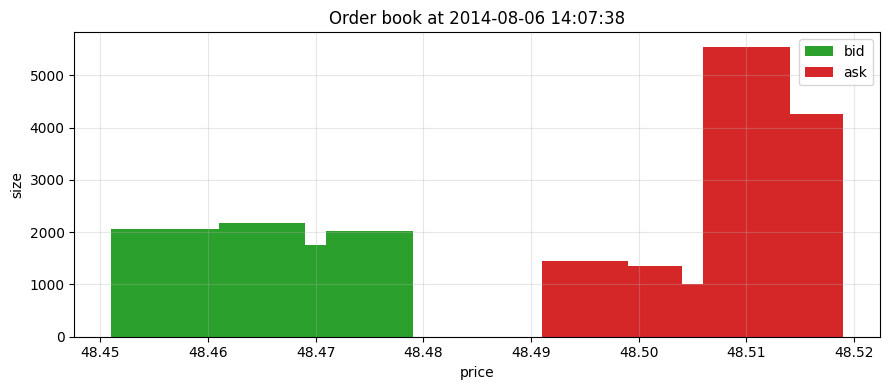

In [3]:
row=book.iloc[len(book)//2]
fig,ax=plt.subplots()
ax.bar([row[p] for p in BID_P],[row[q] for q in BID_Q],width=0.008,color="#2ca02c",label="bid")
ax.bar([row[p] for p in ASK_P],[row[q] for q in ASK_Q],width=0.008,color="#d62728",label="ask")
ax.set_xlabel("price"); ax.set_ylabel("size"); ax.legend(); ax.set_title(f"Order book at {row['dt']}")
plt.tight_layout(); plt.show()

### Figure — Mid-price trajectory (period + zoom)
**What it shows.** Left: the mid over the whole period; right: a zoom on a single day.
**Reading.** Left = slow trend; right = **microstructure** (one-tick jumps) — this is the noise we filter out into "events".

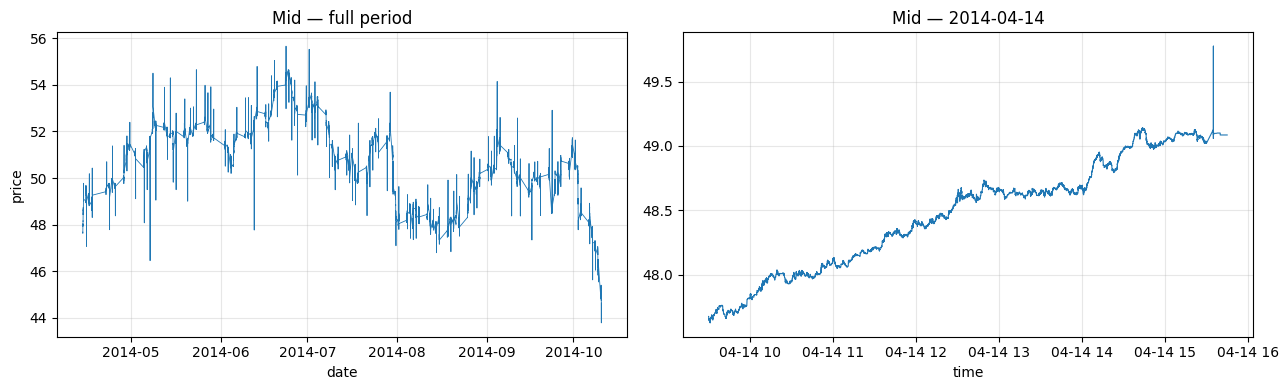

In [4]:
d0=book[book.day==book.day.iloc[0]]
fig,ax=plt.subplots(1,2,figsize=(13,4))
ax[0].plot(book.dt,book.mid,lw=0.6); ax[0].set_title("Mid — full period"); ax[0].set_xlabel("date")
ax[1].plot(d0.dt,d0.mid,lw=0.8); ax[1].set_title(f"Mid — {book.day.iloc[0].date()}"); ax[1].set_xlabel("time")
ax[0].set_ylabel("price"); plt.tight_layout(); plt.show()

## 1bis — Macro / historical context
**Goal.** Place the studied window inside the long-run history of the stock, to judge how representative it is.
**Why it matters.** Over these 6 months the stock is **mildly declining** (≈ **−9%**) in a **relatively calm** regime (volatility below the 2014–2017 median); conclusions drawn here (and the stationarity assumption) need not carry over to stressed or strongly trending regimes. The trade file spans **2014–2017**, so we can build a long price/volatility history and locate our window in it.
**Figure — Reading.** The orange band marks the studied window; note whether it sits in a calm or agitated, typical or atypical part of 2014–2017.

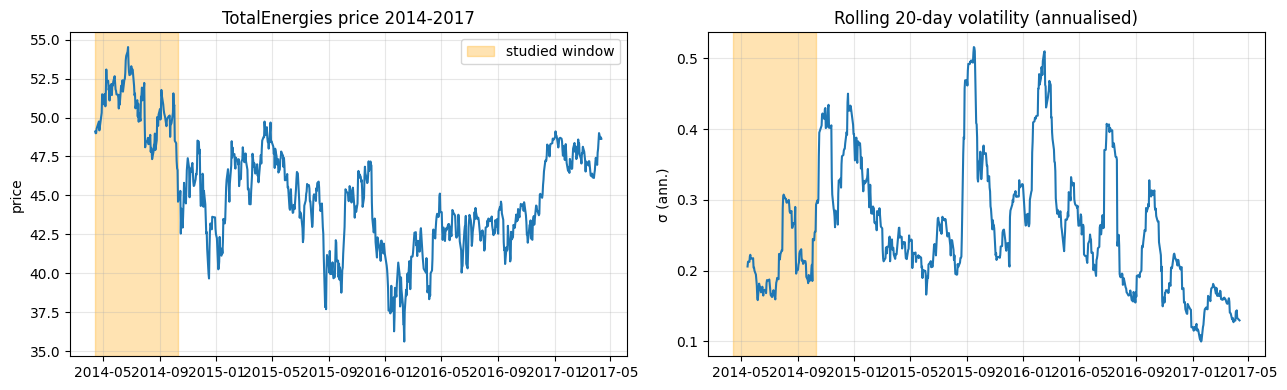

▶ Studied window: return -9.0% ; volatility below the 2014-2017 median → window is relatively calm and trending.


In [5]:
# Long history (2014-2017) from the full trade file; locate the studied window in it.
allt=pd.read_csv(find_file(TRADE_FILE),usecols=lambda c:c in {"date","time","trade.price"})
allt["dt"]=pd.to_datetime(allt["date"]+" "+allt["time"])
daily=allt.set_index("dt")["trade.price"].resample("1D").last().dropna()
ret=np.log(daily).diff(); vol20=ret.rolling(20).std()*np.sqrt(252)
fig,ax=plt.subplots(1,2,figsize=(13,4))
ax[0].plot(daily.index,daily.values); ax[0].axvspan(tmin,tmax,color="orange",alpha=.3,label="studied window")
ax[0].set_title("TotalEnergies price 2014-2017"); ax[0].set_ylabel("price"); ax[0].legend()
ax[1].plot(vol20.index,vol20.values); ax[1].axvspan(tmin,tmax,color="orange",alpha=.3)
ax[1].set_title("Rolling 20-day volatility (annualised)"); ax[1].set_ylabel("σ (ann.)")
plt.tight_layout(); plt.show()
_wret=100*(daily.loc[:tmax].iloc[-1]/daily.loc[tmin:].iloc[0]-1)
_wvol=vol20.loc[tmin:tmax].mean()
print(f"▶ Studied window: return {_wret:+.1f}% ; volatility {'above' if _wvol>vol20.median() else 'below'} the 2014-2017 median → window is {'agitated' if _wvol>vol20.median() else 'relatively calm'} and {'trending' if abs(_wret)>2 else 'flat'}.")

## 2 — Order flow (6 types), tracked **per price level**
**Goal.** Reconstruct 6 flows: **limit / cancel / market (execution)**, on the **bid** and **ask** side.

**Market orders — Lee-Ready classification.** A trade record gives a *price* and a *size* but never says who was the aggressor. The Lee-Ready (1991) rule infers the **side** (buyer- vs seller-initiated) in two steps:
- **① Quote test (primary).** Compare the trade price $p$ to the mid $m=(\text{bid}_1+\text{ask}_1)/2$ quoted *just before* the trade:
  - $p>m$ → **buy** (the trade lifted the ask — the buyer crossed the spread),
  - $p<m$ → **sell** (the trade hit the bid).
- **② Tick test (tie-break, used only when $p=m$).** When the price sits exactly on the mid the quote test is silent, so we look at the move vs the *previous* trade:
  - uptick ($p>p_{\text{prev}}$) → **buy**, downtick ($p<p_{\text{prev}}$) → **sell**,
  - flat ($p=p_{\text{prev}}$) → reuse the **last non-zero** tick direction.
- **Why it works.** A buyer in a hurry must pay up to the ask (above the mid); a seller must accept the bid (below it). The price *relative to the mid* therefore reveals which side initiated. The mid is read from the book snapshot immediately preceding each trade (`merge_asof`, backward), so it is the quote the trade actually faced.

**Limit / cancel — size change at a *fixed price*.** For a price present in two consecutive same-day snapshots: $\Delta Q>0$ → limit, $\Delta Q<0$ → cancellation.
**Avoiding double-counting (R1).** A market order at the best level **also** shrinks the queue, so a raw $\Delta Q<0$ mixes cancellations and executions. We therefore subtract the executed volume:
$$\text{cancel}=\max\!\big(0,\ |\Delta Q|-\text{executed volume at that price}\big).$$
A `market_buy` consumes the **ask**, a `market_sell` consumes the **bid**. This is why the trade classification is computed **before** the book flow below.
**Why per price.** Comparing `bidQ_1` to `bidQ_1` is wrong once the best price moves. Rebuilt **day by day** (bounded memory).

In [6]:
# Market orders (executions): classify each trade with the Lee-Ready rule.
tb=pd.merge_asof(trades,book[["dt","bid_1","ask_1"]],on="dt",direction="backward")
mid=(tb.bid_1+tb.ask_1)/2
tsign=np.sign(tb["trade.price"].diff()).replace(0,np.nan).ffill().fillna(1)
buy=(tb["trade.price"]>mid)|((tb["trade.price"]==mid)&(tsign>0))
tb["order_type"]=np.where(buy,"market_buy","market_sell")
# keep the trade PRICE: R1 needs it to subtract executed volume from cancellations
market=tb[["dt","trade.price","trade.volume","order_type"]].rename(
        columns={"trade.volume":"volume","trade.price":"price"})
print(market.order_type.value_counts().to_string())

order_type
market_sell    313511
market_buy     303474


**Reading.**
- **Balanced count.** Market sells and buys are close in **trade count** → no strong directional imbalance in executions over the period.
- **Caveat deferred.** Whether the small asymmetry is real directional pressure or just a Lee-Ready classification effect is tested on **raw volumes** in the symmetry diagnostic (§11).

In [7]:
def flow_price_keyed(book, P, Q, side, market):
    # NB: this book quotes on a HALF-TICK grid (0.005), so we key prices on TICK/2
    # to avoid merging two distinct price levels into one (which would corrupt the flow).
    GRID=TICK/2
    exec_type = "market_sell" if side=="buy" else "market_buy"   # a market order consuming THIS side
    out=[]; raw_canc=0.0; subtracted=0.0
    for day,g in book.groupby("day", sort=True):
        gi=g.reset_index(drop=True); n=len(gi); day_dt=gi["dt"].values
        long=pd.concat([pd.DataFrame({"i":np.arange(n),
                                      "ptick":np.round(gi[p].values/GRID).astype(np.int64),
                                      "qty":gi[q].values})
                        for p,q in zip(P,Q)],ignore_index=True).sort_values(["ptick","i"])
        gg=long.groupby("ptick",sort=False)
        di=gg["i"].diff().values; dq=gg["qty"].diff().values
        ptick=long["ptick"].values; iidx=long["i"].values
        keep=np.where((di==1)&np.isfinite(dq)&(dq!=0))[0]
        if len(keep)==0: continue
        i_k=iidx[keep]; p_k=ptick[keep]; d_k=dq[keep]
        # executions of the day on THIS side, mapped to the interval ending at snapshot i
        md=market[(market.order_type==exec_type)&(market.dt>=day_dt[0])&(market.dt<=day_dt[-1])]
        ex=None
        if len(md):
            ti=np.searchsorted(day_dt, md["dt"].values, side="left")
            mp=np.round(md["price"].values/GRID).astype(np.int64)   # snap trade price to the book grid
            ex=(pd.DataFrame({"ptick":mp,"i":ti,"v":md["volume"].values})
                  .groupby(["ptick","i"])["v"].sum())
        is_lim=d_k>0
        if is_lim.any():                                  # limit orders: ΔQ>0 (unchanged by R1)
            li=i_k[is_lim]
            out.append(pd.DataFrame({"dt":day_dt[li],"volume":d_k[is_lim],
                                     "order_type":f"limit_order_{side}"}))
        nlim=~is_lim
        if nlim.any():                                    # cancellations: |ΔQ<0| minus executions
            cdf=pd.DataFrame({"i":i_k[nlim],"ptick":p_k[nlim],"neg":-d_k[nlim]})
            raw_canc+=float(cdf["neg"].sum())
            if ex is not None:
                cdf=cdf.merge(ex,left_on=["ptick","i"],right_index=True,how="left")
                cdf["v"]=cdf["v"].fillna(0.0)
            else:
                cdf["v"]=0.0
            cdf["canc"]=np.maximum(0.0, cdf["neg"]-cdf["v"])
            subtracted+=float((cdf["neg"]-cdf["canc"]).sum())
            cdf=cdf[cdf["canc"]>0]
            if len(cdf):
                out.append(pd.DataFrame({"dt":day_dt[cdf["i"].values],"volume":cdf["canc"].values,
                                         "order_type":f"cancellation_{side}"}))
    df=pd.concat(out,ignore_index=True) if out else pd.DataFrame(columns=["dt","volume","order_type"])
    return df,{"raw_canc":raw_canc,"subtracted":subtracted}

t0=time.time()
bf_buy,_db=flow_price_keyed(book,BID_P,BID_Q,"buy",market)
bf_sell,_ds=flow_price_keyed(book,ASK_P,ASK_Q,"sell",market)
book_flow=pd.concat([bf_buy,bf_sell],ignore_index=True)
print(f"book flow in {time.time()-t0:.1f}s"); print(book_flow.order_type.value_counts().to_string())

_raw=_db["raw_canc"]+_ds["raw_canc"]; _sub=_db["subtracted"]+_ds["subtracted"]
_tot=len(book_flow)+len(market); _pct=100*len(market)/_tot
print(f"▶ Market orders = {_pct:.1f}% of all flow events: most activity is passive (limit/cancel).")
print(f"▶ R1: removed {_sub:,.0f} of {_raw:,.0f} raw cancel volume "
      f"({100*_sub/max(_raw,1):.2f}%) that was double-counted with market_* executions.")

book flow in 45.0s
order_type
cancellation_sell    22862061
cancellation_buy     22438118
limit_order_sell     21843393
limit_order_buy      21499725
▶ Market orders = 0.7% of all flow events: most activity is passive (limit/cancel).
▶ R1: removed 56,100,530 of 21,741,732,163 raw cancel volume (0.26%) that was double-counted with market_* executions.


**Reading.**
- **Cancel ≈ limit.** Cancellations and limit orders are of the same order of magnitude on each side: a large fraction of posted liquidity is withdrawn before it ever trades — typical of an electronic book.
- **Side symmetry.** The bid and ask sides stay nearly symmetric.
- **R1 note (▶ above).** The ▶ line reports the share of raw negative ΔQ that was actually *executed* and so reclassified from `cancellation_*` to `market_*` by R1 — cancellation totals here are therefore **net of executions**.

## 3 — Events: *significant price change* → vector $X_n$
**Goal.** Cut time into events bounded by **genuine** price changes, and summarise the order flow of each interval.
**Definition (LOB 101).** A *significant price change* occurs when the **new bid reaches the old ask** (price up) or the **new ask reaches the old bid** (price down) — a directional move of at least one tick.
$$\text{up}:\ \text{bid}_1(t)\ge \text{ask}_1(t-1) \qquad \text{down}:\ \text{ask}_1(t)\le \text{bid}_1(t-1)$$
**Vector**: $X_n=(\Delta t_n, V^{lo,b},V^{lo,a}, V^{c,b},V^{c,a}, V^{ex,b},V^{ex,a}, r_n)$, with $\Delta t_n=t_n-t_{n-1}$ and $r_n=(\text{mid}_n-\text{mid}_{n-1})/\text{tick}$ (**in ticks**, **per day**).
**Why per day.** Diffs reset at each session start, so no overnight gap pollutes $\Delta t$ or $r$.

In [8]:
# detect significant price changes (per day)
prev_ask=book["ask_1"].shift(); prev_bid=book["bid_1"].shift()
same=book["day"].eq(book["day"].shift())
book["spc"]=(((book["bid_1"]>=prev_ask)|(book["ask_1"]<=prev_bid))&same).fillna(False)
spc=book.loc[book["spc"],["dt","day","mid"]].reset_index(drop=True)
spc["event_id"]=spc.index+1
spc["dt_sec"]=spc.groupby("day")["dt"].diff().dt.total_seconds()
spc["r"]=spc.groupby("day")["mid"].diff()/TICK
print(f"{len(spc):,} significant price changes")

# assign the flow to each event interval + aggregate
flow=pd.concat([market,book_flow],ignore_index=True).sort_values("dt").reset_index(drop=True)
flow["event_id"]=np.searchsorted(spc["dt"].values, flow["dt"].values, side="right")
vol=(flow[flow.event_id>=1].pivot_table(index="event_id",columns="order_type",
        values="volume",aggfunc="sum",fill_value=0).add_prefix("vol_"))
ev=spc.merge(vol,left_on="event_id",right_index=True,how="left").rename(columns={"dt":"end_dt","mid":"end_mid"})
for t in OT:
    if f"vol_{t}" not in ev: ev[f"vol_{t}"]=0.0
ev[[f"vol_{t}" for t in OT]]=ev[[f"vol_{t}" for t in OT]].fillna(0.0)
ev["dt_sec"]=ev["dt_sec"].clip(lower=0)
ev=ev.dropna(subset=["r"]); ev=ev[ev["r"].abs()<=50].reset_index(drop=True)
print(f"usable events: {len(ev):,} | r in ticks (min {ev.r.min():.0f}, max {ev.r.max():.0f})")

_cap=int((ev["r"].abs()>=49.9).sum())
print("▶ Returns are mostly ±1 tick. " + (f"⚠ {_cap} events at the ±50-tick cap (extreme jumps: opening/auction quotes to check)." if _cap>0 else "No extreme jumps."))

699,711 significant price changes
usable events: 698,988 | r in ticks (min -50, max 50)
▶ Returns are mostly ±1 tick. ⚠ 10 events at the ±50-tick cap (extreme jumps: opening/auction quotes to check).


**Reading.**
- **Few dropped.** Almost all significant price changes survive the filters — only a handful are removed (missing return, or |r| > 50 ticks): out of ~700k events just **10** hit the ±50-tick cap, as reported by the ▶ line above.
- **Cap is harmless.** The ±50-tick cap removes only rare extreme jumps (opening/overnight), so essentially the whole 6-month window stays exploitable.

### Figure — Heavy tails (CCDF of volumes and of returns)
**What it shows.** $P(X>x)$ on log-log axes, for the volumes (left) and for $|r|$ (right).
**Reading.** A straight line in log-log = a power law = heavy tails. Heavy tails are **confirmed for volumes** (many decades). For **returns**, at the *event* scale they are essentially ±1 tick → **no heavy tail is expected here**; the "fat tails" stylised fact must be tested on **aggregated** returns (see §6, after binning).

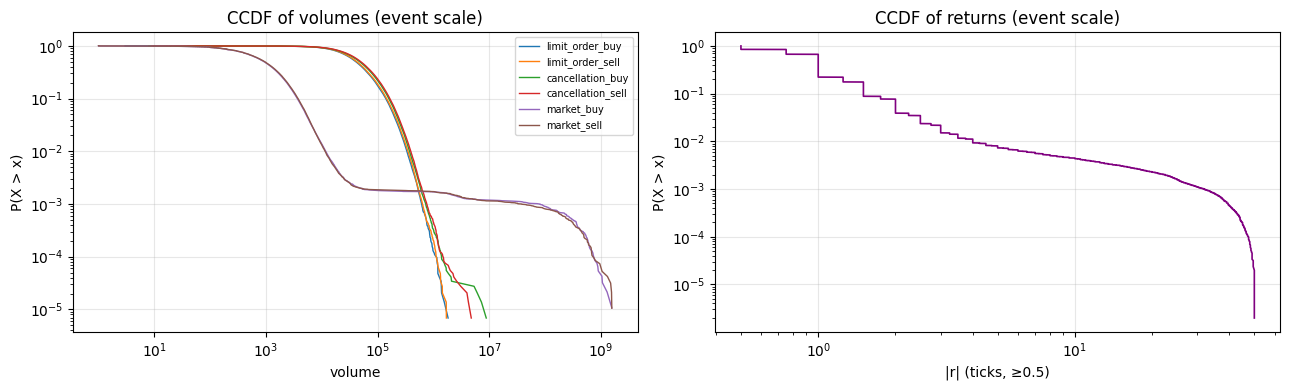

▶ |r| spans only ~2.0 decade(s) at the event scale → too few for a power law; heavy tails belong to the binned returns (§6).


In [9]:
fig,ax=plt.subplots(1,2,figsize=(13,4))
for v in VOL:
    x=np.sort(ev[v][ev[v]>0].values)
    if len(x)>10: ax[0].loglog(x,1-np.arange(len(x))/len(x),lw=1,label=v.replace("vol_",""))
ax[0].set_xlabel("volume"); ax[0].set_ylabel("P(X > x)"); ax[0].legend(fontsize=7)
ax[0].set_title("CCDF of volumes (event scale)")
# returns: drop floating-point dust (<0.5 tick = numerical noise); test tails only above 0.5 tick
ar=np.abs(ev["r"].values); ar=np.sort(ar[ar>=0.5])
ax[1].loglog(ar,1-np.arange(len(ar))/len(ar),lw=1.2,color="purple")
ax[1].set_xlabel("|r| (ticks, ≥0.5)"); ax[1].set_ylabel("P(X > x)")
ax[1].set_title("CCDF of returns (event scale)")
plt.tight_layout(); plt.show()
print(f"▶ |r| spans only ~{np.log10(ar.max()/ar.min()):.1f} decade(s) at the event scale → too few for a power law; heavy tails belong to the binned returns (§6).")

### Figure — Correlation of the $X_n$ variables
**What it shows.** Correlations among the 8 variables.
**Reading.** Correlated **blocks** (e.g. limit/cancel on the same side) → this is what **justifies the PCA**.

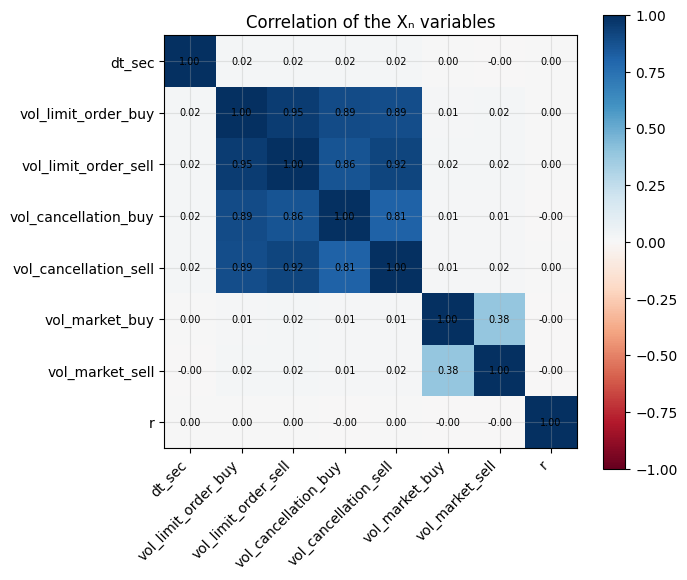

In [10]:
C=ev[COLS].astype(float).corr()
fig,ax=plt.subplots(figsize=(7,6)); im=ax.imshow(C,cmap="RdBu",vmin=-1,vmax=1)
ax.set_xticks(range(len(COLS))); ax.set_xticklabels(COLS,rotation=45,ha="right")
ax.set_yticks(range(len(COLS))); ax.set_yticklabels(COLS)
for i in range(len(COLS)):
    for j in range(len(COLS)): ax.text(j,i,f"{C.values[i,j]:.2f}",ha="center",va="center",fontsize=7)
fig.colorbar(im,ax=ax); ax.set_title("Correlation of the Xₙ variables"); plt.tight_layout(); plt.show()

## 4 — Stylised facts
**Goal.** Reproduce the stylised facts (LOB 101): bid-ask bounce, volatility clustering, **long memory of the flow**, **concave market impact**.
**ACF** (via `statsmodels`): $\hat\rho_r(1)<0$ (bounce), $\hat\rho_{|r|}>0$ decaying slowly (clustering), $\hat\rho_{\text{flow}}$ decays **slowly** (long memory).

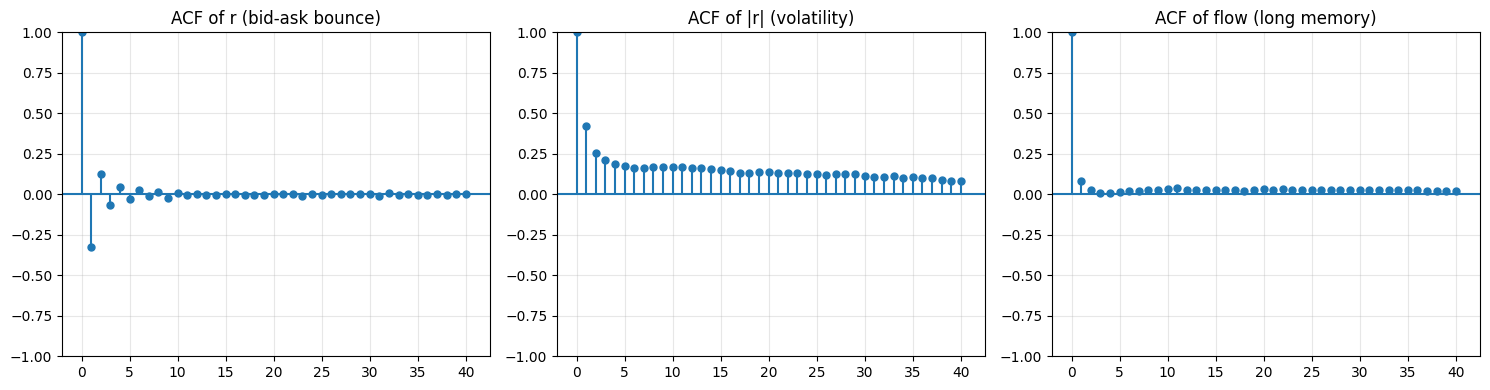

ρ_r(1) = -0.327
▶ Bid-ask bounce confirmed (ρ_r(1)<0); the flow stays autocorrelated (≈+0.03 at lag 10) → long memory.


In [11]:
nl=int(min(40, len(ev)//2-1))
fig,ax=plt.subplots(1,3,figsize=(15,4))
plot_acf(ev["r"].values, ax=ax[0], lags=nl, title="ACF of r (bid-ask bounce)")
plot_acf(np.abs(ev["r"].values), ax=ax[1], lags=nl, title="ACF of |r| (volatility)")
plot_acf(ev["vol_limit_order_buy"].values, ax=ax[2], lags=nl, title="ACF of flow (long memory)")
plt.tight_layout(); plt.show()
print(f"ρ_r(1) = {sm_acf(ev.r.values,nlags=1,fft=True)[1]:+.3f}")

_fl=sm_acf(ev.vol_limit_order_buy.values,nlags=10,fft=True)[10]
print(f"▶ Bid-ask bounce confirmed (ρ_r(1)<0); the flow stays autocorrelated (≈{_fl:+.2f} at lag 10) → long memory.")

**Reading.**
- **Bid-ask bounce.** $\hat\rho_r(1)$ is strongly **negative** (printed above): an up-move tends to be followed by a down-move — the expected stylised fact.
- **Handled later.** This is exactly the noise that binning (§6) will neutralise.

### Figure — Market impact (square-root law)
**What it shows.** The average price move $|r|$ as a function of the market volume executed in the event, on **log-log** axes with **log-spaced** bins, against a $\sqrt{\cdot}$ reference.
**Reading.** If the points lie on a line of slope ≈ 0.5, doubling the volume does **not** double the impact (*square-root law*, LOB 101). We read the **fitted slope** rather than assume the exponent; the printed value says whether the square-root law is supported.

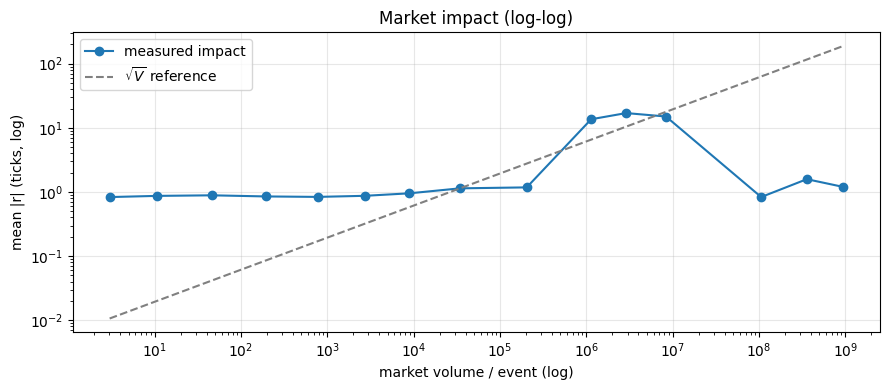

▶ Impact exponent ≈ 0.08 → not a clean square-root.


In [12]:
ev["Vex"]=ev["vol_market_buy"]+ev["vol_market_sell"]
m=ev[ev["Vex"]>0].copy()
edges=np.geomspace(m["Vex"].min(), m["Vex"].max(), 16)        # LOG-spaced bins
m["q"]=pd.cut(m["Vex"], edges)
agg=m.groupby("q",observed=True).agg(v=("Vex","mean"),
        imp=("r",lambda s:np.abs(s).mean())).dropna()
fig,ax=plt.subplots()
ax.loglog(agg["v"],agg["imp"],"o-",label="measured impact")
_k=len(agg)//2                                                # robust anchor (median bin)
vv=np.geomspace(agg["v"].min(),agg["v"].max(),50)
ax.loglog(vv, agg["imp"].iloc[_k]*np.sqrt(vv/agg["v"].iloc[_k]),"--",color="grey",
          label=r"$\sqrt{V}$ reference")
ax.set_xlabel("market volume / event (log)"); ax.set_ylabel("mean |r| (ticks, log)")
ax.set_title("Market impact (log-log)"); ax.legend(); plt.tight_layout(); plt.show()
_b=float(np.polyfit(np.log(agg["v"]),np.log(agg["imp"]+1e-12),1)[0])
print(f"▶ Impact exponent ≈ {_b:.2f} " + ("(square-root law, slope ≈ 0.5)." if 0.4<=_b<=0.6 else "→ not a clean square-root."))

## 5 — Intraday profile (estimated **on the train set**)
**Goal.** Remove the time-of-day seasonality from the volumes.
**Method.** Divide each volume by its 30-min time-slot mean, **computed on the train set only** (no leakage).
**Figure — Intraday profile.** **Reading**: a **U-shape** (open/close peaks); we normalise so as not to confuse activity with time of day.

> **Δt too.** We also deseasonalise **Δt**: otherwise it keeps an intraday seasonality (longer durations around midday) that makes **KPSS reject** while ADF sees nothing. Δt then becomes a **relative duration** (relative to the time of day) — so its sum over a bin (§6) no longer carries the dimension "seconds" (legitimate, but worth stating explicitly).

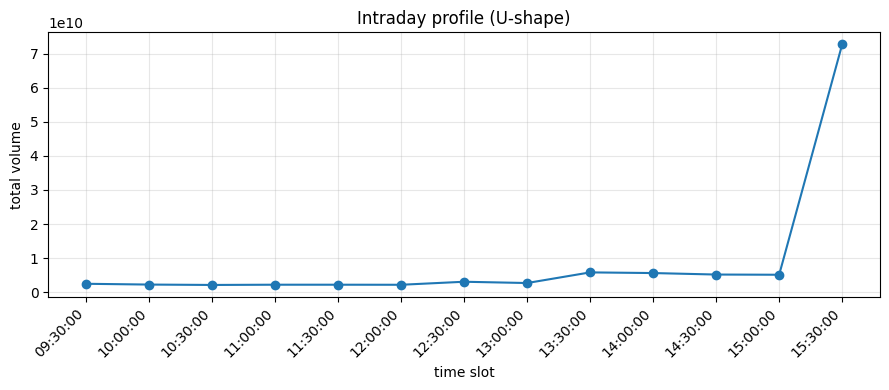

Volumes AND Δt deseasonalised by the intraday profile (estimated on the train set).
▶ U-shape (open/close peaks): we remove the time-of-day effect so as not to confuse activity with hour.


In [13]:
n_tr_ev=int(TRAIN_FRAC*len(ev))
ev["slot"]=ev["end_dt"].dt.floor("30min").dt.time
NORM=VOL+["dt_sec"]   # deseasonalise Δt as well (otherwise KPSS rejects)
slot_mean=ev.iloc[:n_tr_ev].groupby("slot")[NORM].mean().replace(0,np.nan)
denom=slot_mean.reindex(ev["slot"].values).reset_index(drop=True)
for v in NORM: ev[v]=ev[v].values/denom[v].values
ev[NORM]=ev[NORM].fillna(1.0)
prof=(flow.assign(slot=flow.dt.dt.floor("30min").dt.time).groupby("slot")["volume"].sum())
fig,ax=plt.subplots()
ax.plot(range(len(prof)),prof.values,"o-"); st=max(1,len(prof)//8)
ax.set_xticks(range(0,len(prof),st)); ax.set_xticklabels([str(t) for t in prof.index[::st]],rotation=45,ha="right")
ax.set_xlabel("time slot"); ax.set_ylabel("total volume"); ax.set_title("Intraday profile (U-shape)")
plt.tight_layout(); plt.show()
print("Volumes AND Δt deseasonalised by the intraday profile (estimated on the train set).")
print("▶ U-shape (open/close peaks): we remove the time-of-day effect so as not to confuse activity with hour.")

## 6 — Binning (per day)
**Goal.** Decorrelate the returns. **Method.** Sum $N$ consecutive events (volumes, $\Delta t$, $r$) **within the day**. **Output**: $|\hat\rho_r(1)|$ after binning (target $<0.01$).
**Why calibrate $N$ (R7).** Instead of borrowing $N=20$ from the thesis blindly, we **scan** $N$ and report the $\rho_r(1)$-vs-$N$ curve. The curve is non-monotonic. On the **full 6 months no $N$ in the scanned grid reaches the $<0.01$ target** (the event-scale bounce is strong, $\rho_r(1)\approx-0.33$), so the rule keeps the **largest scanned $N$** ($N=40$): binning then **attenuates** the bounce by ~10× (down to $\approx-0.03$) but does **not** fully remove it. A volume/trade clock (homogeneous-duration bins) or a microstructure-noise model (MA(1)/Roll) would push the residual bounce lower while discarding fewer observations — noted in the limitations.

N= 5 → ρ_r(1)=-0.0296
N=10 → ρ_r(1)=-0.0378
N=15 → ρ_r(1)=-0.0659
N=20 → ρ_r(1)=-0.0439
N=30 → ρ_r(1)=-0.0543
N=40 → ρ_r(1)=-0.0653
▶ N with |ρ_r(1)|<0.01: [] → keep N_BIN=40 (no N in the grid reaches the 0.01 target on the full 6 months → keep the largest scanned N; the bounce is only attenuated, not removed (see §6 reading / limitations)).
17,537 bins (from 698,988 events, 97% reduction) | ρ_r(1) after binning: -0.0316
▶ ⚠ |ρ_r(1)|=0.0316 ≥ 0.01 → increase N_BIN.


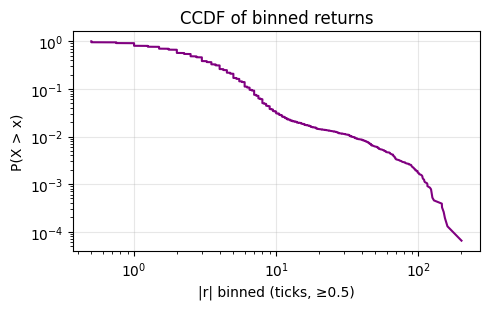

▶ Binned |r| spans ~2.6 decade(s) → heavy tails emerge after aggregation (unlike the event scale, §3).


In [14]:
# R7 — calibrate N via the autocorrelation curve rather than borrowing it blindly
grid=[5,10,15,20,30,40]; rho={}
for Ntest in grid:
    bb=ev.groupby("day").cumcount()//Ntest
    rr=ev.groupby([ev["day"],bb])["r"].sum().values
    rho[Ntest]=sm_acf(rr,nlags=1,fft=True)[1]
    print(f"N={Ntest:2d} → ρ_r(1)={rho[Ntest]:+.4f}")
_ok=[Ntest for Ntest in grid if abs(rho[Ntest])<0.01]
# the curve is non-monotonic; keep the thesis value N=20 if the scan confirms it,
# else the smallest passing N, else (no N passes on the full 6 months) the largest scanned N.
N_BIN = 20 if (20 in _ok) else (_ok[0] if _ok else grid[-1])
_why = ("thesis value, confirmed by the scan" if 20 in _ok
        else "smallest N meeting the target" if _ok
        else "no N in the grid reaches the 0.01 target on the full 6 months → keep the largest scanned N; the bounce is only attenuated, not removed (see §6 reading / limitations)")
print(f"▶ N with |ρ_r(1)|<0.01: {_ok} → keep N_BIN={N_BIN} ({_why}).")

ev["bin"]=ev.groupby("day").cumcount()//N_BIN
ev["binkey"]=ev["day"].astype(str)+"_"+ev["bin"].astype(str)
data=(ev.groupby("binkey").agg(start_dt=("end_dt","first"),end_dt=("end_dt","last"),
        dt_sec=("dt_sec","sum"),r=("r","sum"),**{v:(v,"sum") for v in VOL})
      .sort_values("start_dt").reset_index(drop=True))
data["day"]=data["start_dt"].dt.normalize()
X=data[COLS].astype(float)
_b1=sm_acf(data.r.values,nlags=1,fft=True)[1]
_red=100*(1-len(data)/len(ev))
print(f"{len(data):,} bins (from {len(ev):,} events, {_red:.0f}% reduction) | ρ_r(1) after binning: {_b1:+.4f}")
print("▶ " + (f"|ρ_r(1)|={abs(_b1):.4f} < 0.01 → returns decorrelated, ready for the VAR." if abs(_b1)<0.01 else f"⚠ |ρ_r(1)|={abs(_b1):.4f} ≥ 0.01 → increase N_BIN."))

# R4 — heavy-tail check on BINNED returns (where fat tails are actually expected)
_rb=np.sort(np.abs(data["r"].values)); _rb=_rb[_rb>=0.5]
if len(_rb)>10:
    fig,ax=plt.subplots(figsize=(5,3.2))
    ax.loglog(_rb,1-np.arange(len(_rb))/len(_rb),color="purple")
    ax.set_xlabel("|r| binned (ticks, ≥0.5)"); ax.set_ylabel("P(X > x)"); ax.set_title("CCDF of binned returns")
    plt.tight_layout(); plt.show()
    print(f"▶ Binned |r| spans ~{np.log10(_rb.max()/_rb.min()):.1f} decade(s) → heavy tails emerge after aggregation (unlike the event scale, §3).")

**Reading.**
- **Strongly attenuated, not eliminated.** Binning cuts $|\hat\rho_r(1)|$ from ≈ **0.33** (event scale) to ≈ **0.03** (binned) — about a **10× reduction** — but on the full 6 months **no $N$ in the scanned grid reaches the 0.01 target** (see the ▶/⚠ above). A small residual bid-ask bounce remains; the VAR works on these mostly-decorrelated $r$, and we revisit the residual in the limitations.
- **Fat tails emerge.** Aggregation reveals the heavy tails of returns (CCDF above) that were absent at the event scale — the "fat tails" stylised fact lives at the **aggregated** scale.
- **The cost.** We discard most observations (≈ **97%** reduction, printed above) — a trade-off we revisit in the limitations.

## 7 — Train / validation / test split + transformation
**Goal.** An honest evaluation + stabilised variables.
**Chronological split**: train 70%, validation 15%, test 15%.
**Transformation.** Yeo-Johnson (generalises **Box-Cox** $y^{(\lambda)}=(y^\lambda-1)/\lambda$; handles zeros/negatives) + standardisation $z=(x-\mu)/\sigma$, **fitted on the train set**.

In [15]:
n=len(X); i_tr=int(TRAIN_FRAC*n); i_val=int((TRAIN_FRAC+VAL_FRAC)*n)
print(f"train [:{i_tr}] | validation [{i_tr}:{i_val}] | test [{i_val}:]  (total {n} bins)")
pt=PowerTransformer(method="yeo-johnson",standardize=True); pt.fit(X.iloc[:i_tr].values)
Xs=pd.DataFrame(pt.transform(X.values),columns=COLS,index=X.index)

train [:12275] | validation [12275:14906] | test [14906:]  (total 17537 bins)


## 8 — Stationarity: **per day**
**Goal.** Check stationarity without being fooled by pooling.
**Why per day.** Over 6 pooled months a series can *look* stationary by accident. We test **day by day** (event level) with **ADF** ($p<0.05$ = stationary) and **KPSS** ($p>0.05$ = stationary).
**Table — Reading.** If "pooled ADF" says stationary but "% of days" is low → the 6-month stationarity was misleading.

In [16]:
rows=[]
for c in COLS:
    p_pool=adfuller(ev[c].values,autolag="AIC")[1]; padf=[]; pkps=[]
    for _,g in ev.groupby("day"):
        s=g[c].values
        if len(s)>=50:
            try: padf.append(adfuller(s,autolag="AIC")[1])
            except Exception: pass
            try:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore"); pkps.append(kpss(s,regression="c",nlags="auto")[1])
            except Exception: pass
    padf=np.array(padf) if padf else np.array([np.nan]); pkps=np.array(pkps) if pkps else np.array([np.nan])
    rows.append({"variable":c,"pooled ADF":round(p_pool,3),"ADF med/day":round(np.nanmedian(padf),3),
                 "% days ADF stat.":round(100*np.nanmean(padf<0.05),0),
                 "KPSS med/day":round(np.nanmedian(pkps),3),"% days KPSS stat.":round(100*np.nanmean(pkps>0.05),0)})
tbl=pd.DataFrame(rows).set_index("variable")
_susp=[c for c in COLS if tbl.loc[c,"% days KPSS stat."]<50]
print("▶ ADF: stationary everywhere. " + ("KPSS OK on most days" + (f" (deseasonalised Δt: {tbl.loc['dt_sec','% days KPSS stat.']:.0f}% of days ✓)." if 'dt_sec' in tbl.index else ".") if not _susp else "⚠ KPSS rejects on most days for: "+", ".join(_susp)+f" (Δt: {tbl.loc['dt_sec','% days KPSS stat.']:.0f}%)."))
tbl

▶ ADF: stationary everywhere. ⚠ KPSS rejects on most days for: dt_sec, vol_limit_order_buy, vol_limit_order_sell (Δt: 44%).


,pooled ADF,ADF med/day,% days ADF stat.,KPSS med/day,% days KPSS stat.
variable,,,,,
dt_sec,0.0,0.0,100.0,0.026,44.0
vol_limit_order_buy,0.0,0.0,100.0,0.036,44.0
vol_limit_order_sell,0.0,0.0,100.0,0.026,44.0
vol_cancellation_buy,0.0,0.0,100.0,0.060,51.0
vol_cancellation_sell,0.0,0.0,100.0,0.055,52.0
vol_market_buy,0.0,0.0,100.0,0.100,79.0
vol_market_sell,0.0,0.0,100.0,0.100,68.0
r,0.0,0.0,98.0,0.100,86.0


**Reading.**
- **ADF vs KPSS.** ADF declares every variable stationary on essentially every day (pooled $p=0$, ~98–100% of days). KPSS (stricter) is more demanding over 6 months: it confirms stationarity on a clear **majority** of days for the **market-order volumes and the return** (≈68–86%), but only on ≈**44–52%** of days for $\Delta t$, the **limit-order** and **cancellation** volumes.
- **Δt deseasonalisation still helps.** Thanks to the $\Delta t$ deseasonalisation (R2/§5), `dt_sec` is no longer *catastrophically* worse than the rest; over the full 6 months it nonetheless sits **among the weakest** (≈44% of days, like the limit-order volumes) — more day-to-day heterogeneity surfaces in a longer sample.
- **What the rejections mean.** The day-to-day KPSS rejections reflect mild intra-day structure, not a global unit root — exactly what the per-day test is designed to expose (pooling the 6 months would have hidden it; here it genuinely does).

## 9 — PCA: microstructure modes
**Goal.** Extract **decorrelated**, interpretable components (the VAR inputs).
**Maths.** $C\,U_\alpha=\lambda_\alpha U_\alpha$, $\sum\lambda=8$; $Y_n=U^\top X^{\text{std}}_n$. **Fitted on the train set**; we keep all 8 modes.
**Why standardise first.** The 8 variables live on very different scales (durations, volumes, ticks); without standardisation the PCA would simply track the largest-variance variable instead of the genuine co-movements.
**Figure — Scree + cumulative variance.** **Reading**: bars = variance per mode; curve = how many modes suffice.
**Figure — Loadings.** **Reading**: volumes with the same sign → **activity**; bid vs ask + $r$ → **imbalance**; $\Delta t$ → **duration**; limit/cancel → **liquidity**.

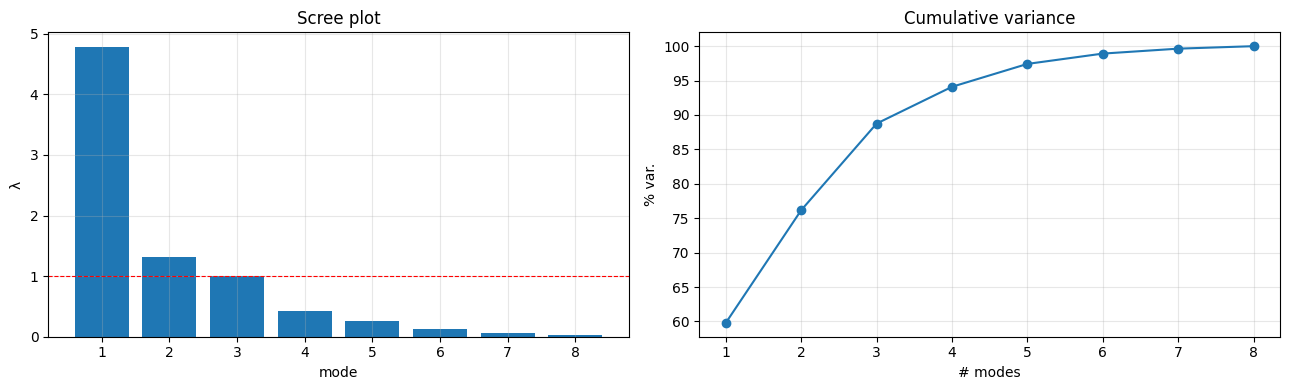

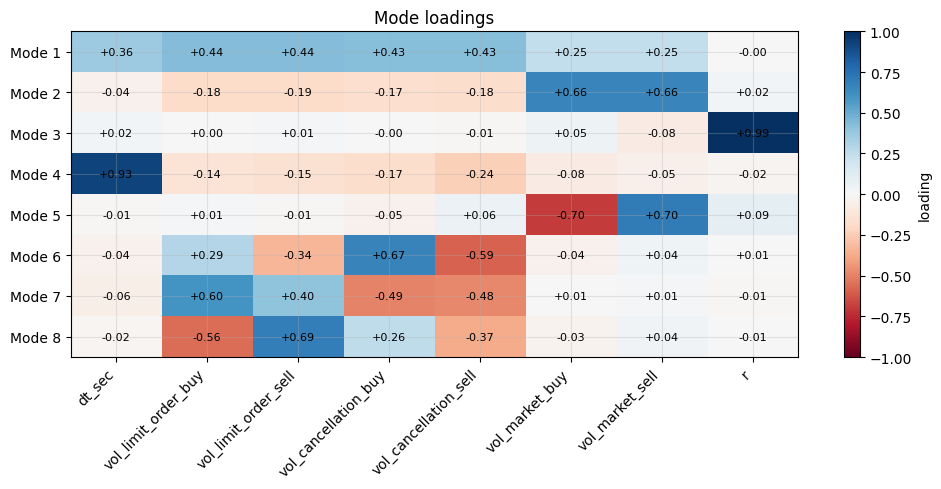

Mode 1: 60% | 3 modes: 89%
▶ Mode 1 (60%) captures global activity; 3 modes reach 80% of the variance.


In [17]:
pca=PCA().fit(Xs.iloc[:i_tr].values)
Y=pca.transform(Xs.values); k=Y.shape[1]
modes=[f"Mode {i+1}" for i in range(k)]; Ydf=pd.DataFrame(Y,columns=modes,index=Xs.index)
eig,ratio=pca.explained_variance_,pca.explained_variance_ratio_
fig,ax=plt.subplots(1,2,figsize=(13,4))
ax[0].bar(range(1,k+1),eig); ax[0].axhline(1,color="r",ls="--",lw=0.8)
ax[0].set_xlabel("mode"); ax[0].set_ylabel("λ"); ax[0].set_title("Scree plot")
ax[1].plot(range(1,k+1),np.cumsum(ratio)*100,"o-"); ax[1].set_xlabel("# modes"); ax[1].set_ylabel("% var.")
ax[1].set_title("Cumulative variance"); plt.tight_layout(); plt.show()
load=pd.DataFrame(pca.components_,index=modes,columns=COLS)
fig,ax=plt.subplots(figsize=(10,5)); im=ax.imshow(load.values,cmap="RdBu",vmin=-1,vmax=1,aspect="auto")
ax.set_xticks(range(len(COLS))); ax.set_xticklabels(COLS,rotation=45,ha="right")
ax.set_yticks(range(k)); ax.set_yticklabels(modes)
for i in range(k):
    for j in range(len(COLS)): ax.text(j,i,f"{load.values[i,j]:+.2f}",ha="center",va="center",fontsize=8)
fig.colorbar(im,ax=ax,label="loading"); ax.set_title("Mode loadings"); plt.tight_layout(); plt.show()
print(f"Mode 1: {ratio[0]*100:.0f}% | 3 modes: {np.cumsum(ratio)[2]*100:.0f}%")
print(f"▶ Mode 1 ({ratio[0]*100:.0f}%) captures global activity; {int((np.cumsum(ratio)>=0.8).argmax()+1)} modes reach 80% of the variance.")

In [18]:
# R9 — control at the EVENT scale (no binning): is the flow->price decoupling real or induced by binning?
from sklearn.preprocessing import StandardScaler
Xe=ev[COLS].astype(float)
sc=StandardScaler().fit(Xe.iloc[:n_tr_ev].values)
Xe_s=pd.DataFrame(sc.transform(Xe.values),columns=COLS)
pca_e=PCA().fit(Xe_s.iloc[:n_tr_ev].values)
load_e=pd.DataFrame(pca_e.components_,columns=COLS)
imb_ev=ev["vol_market_buy"]-ev["vol_market_sell"]
imb_bin=data["vol_market_buy"]-data["vol_market_sell"]
c_evt=np.corrcoef(ev["r"].values, imb_ev.values)[0,1]
c_bin=np.corrcoef(data["r"].values, imb_bin.values)[0,1]
print(f"corr(r, market imbalance)  event = {c_evt:+.3f}  |  bin = {c_bin:+.3f}")
print(f"Variable on which r loads most (event PCA): {load_e['r'].abs().idxmax()}  ({load_e['r'].abs().max():.2f})")
print("▶ " + ("|corr| is markedly larger at the event scale → binning DILUTES the flow->price link; the 'efficient market' reading holds at the BIN scale only." if abs(c_evt)>abs(c_bin)+0.02 else "both correlations are ~0 → the decoupling is robust across scales."))

corr(r, market imbalance)  event = -0.000  |  bin = +0.012
Variable on which r loads most (event PCA): 2  (0.73)
▶ both correlations are ~0 → the decoupling is robust across scales.


**Reading.**
- **Few factors.** Mode 1 captures the bulk of the variance (≈ **60%**, printed above) and **3 modes reach ~80–89%**: microstructure reduces to very few factors, dominated by a "global activity" mode — precisely what justifies the PCA before the VAR.
- **r ⟂ flows.** At the **bin** scale the return is nearly orthogonal to the flows (→ efficient market).
- **Is it real? (R9).** The event-scale control (R9, above) checks whether this decoupling is genuine or binning-induced, by comparing corr(r, market imbalance) at the **event** vs the **bin** scale. Here **both are ≈ 0** (event −0.00, bin +0.01) → the decoupling is **robust across scales**, not an artefact of binning.

## 10 — VAR: information criteria **and** validation
**Goal.** Estimate $Y_n=c+\sum_{j=1}^p\Phi_jY_{n-j}+\varepsilon_n$ and choose the order `p`.
**Method.** We first show **AIC / BIC / HQIC** (VAR 101 workflow). But we **choose `p` on the validation R²** (never the test), because BIC under-fits and the flow has long memory. The final model is re-estimated on **train + validation**.
**Figure — R²(p) on the validation set.** **Reading**: R² rises with `p` while memory is useful, then plateaus; we keep the `p` at the maximum.

Information criteria (VAR 101):
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -8.853      -8.848   0.0001430      -8.851
1       -10.14      -10.10   3.949e-05      -10.12
2       -10.44      -10.36   2.917e-05      -10.41
3       -10.59      -10.46   2.528e-05      -10.54
4       -10.65     -10.49*   2.378e-05      -10.59
5       -10.68      -10.48   2.309e-05     -10.61*
6       -10.69      -10.45   2.282e-05      -10.61
7       -10.70      -10.42   2.263e-05      -10.60
8       -10.70      -10.38   2.258e-05      -10.59
9       -10.70      -10.35   2.254e-05      -10.58
10      -10.71      -10.31   2.241e-05      -10.57
11      -10.71      -10.28   2.242e-05      -10.56
12     -10.71*      -10.24  2.241e-05*      -10.55
--------------------------------------------------


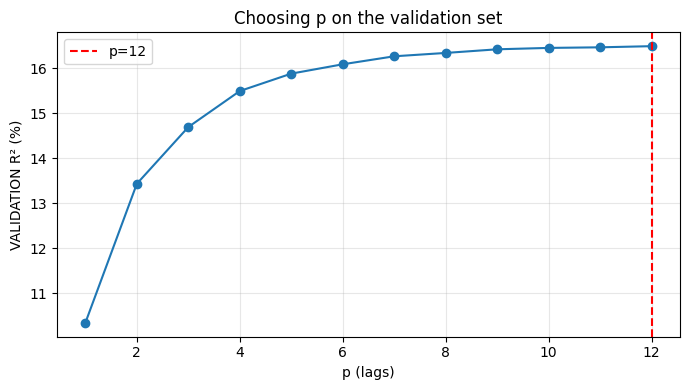

AIC→12, BIC→4, HQIC→5 | validation choice: p=12 | stable=True
▶ BIC under-fits (p=4); validation keeps p=12. R² keeps rising with p → long memory.


In [19]:
pmax=max(1,min(PMAX,int((i_tr-1)/(k+1))-1))
order=VAR(Ydf.iloc[:i_tr]).select_order(maxlags=pmax)
print("Information criteria (VAR 101):"); print(order.summary())

def one_step(Cf,c,M,t):
    y=c.copy()
    for j in range(Cf.shape[0]): y=y+Cf[j]@M[t-1-j]
    return y
def block_r2(Cf,c,M,lo,hi):
    p=Cf.shape[0]; lo2=max(lo,p)
    pr=np.array([one_step(Cf,c,M,t) for t in range(lo2,hi)]); A=M[lo2:hi]
    st=((A-A.mean(0))**2).sum(0); return np.nanmean(1-((A-pr)**2).sum(0)/np.where(st>0,st,np.nan))
M=Ydf.values; val=[]
for p in range(1,pmax+1):
    try: rp=VAR(Ydf.iloc[:i_tr]).fit(p); val.append(block_r2(rp.coefs,rp.intercept,M,i_tr,i_val))
    except Exception: val.append(np.nan)
P=int(np.nanargmax(val))+1
fig,ax=plt.subplots(figsize=(7,4))
ax.plot(range(1,pmax+1),100*np.array(val),"o-"); ax.axvline(P,color="r",ls="--",label=f"p={P}")
ax.set_xlabel("p (lags)"); ax.set_ylabel("VALIDATION R² (%)"); ax.set_title("Choosing p on the validation set"); ax.legend()
plt.tight_layout(); plt.show()
res=VAR(Ydf.iloc[:i_val]).fit(P)
print(f"AIC→{order.aic}, BIC→{order.bic}, HQIC→{order.hqic} | validation choice: p={P} | stable={res.is_stable()}")

print(f"▶ BIC under-fits (p={order.bic}); validation keeps p={P}. " + ("Validation R² plateaus early: binning absorbed short memory (residual long memory shows up in §11)." if P<=3 else "R² keeps rising with p → long memory."))

**Reading.**
- **Criteria disagree.** AIC, HQIC and BIC (printed above) point to different orders, as expected: AIC over-parametrises (here $p=12$), BIC under-fits (here $p=4$).
- **Validation decides.** The validation set settles the choice — here it keeps the **maximum** lag $p=12$ (the validation R² is still rising at the lag ceiling), and the model is stable.
- **Same conclusion either way.** Whichever `p` wins: binning largely controls the short-term bid-ask bounce, and the extra gain from longer lags reflects the flow's residual **long memory**, not predictable returns (the test-set $r$ stays unpredictable, §12).

## 11 — Diagnostics (+ bid/ask symmetry)
**Goal.** Validate the model.
**Stability**: companion eigenvalues $|\lambda|<1$. **White noise**: Ljung-Box ($p>0.05$). **Residual ACF/PACF** (VAR 101) should stay inside the band. **Symmetry**: bid vs ask volumes ≈ 1.
**Figure — Unit circle + residual ACF + PACF.** **Reading**: points inside the circle = stable; ACF/PACF inside the band = white residuals.

> **Reading the diagnostics.** On 2000+ observations **Ljung-Box rejects even a tiny residual autocorrelation**, so we also report its **magnitude** (≈ negligible if < 0.10). Symmetry is measured on **raw volumes**. A market-order asymmetry is a **directional pressure** only if the **net volume** and the **price change** point the **same way**; otherwise it is a classification effect.

Stable: True | max |λ| = 0.963
Ljung-Box p = 0.0000  (residuals still correlated)
  limit_order  buy/sell (RAW volumes) = 0.96  (≈1 expected)
  cancellation buy/sell (RAW volumes) = 0.96  (≈1 expected)
  market       buy/sell (RAW volumes) = 1.03  (≈1 expected)
Max residual autocorrelation (lags 1-10, all modes) = 0.016
Net market volume (buy-sell, raw) = +1228371513  |  cumulative intraday price change = -49 ticks


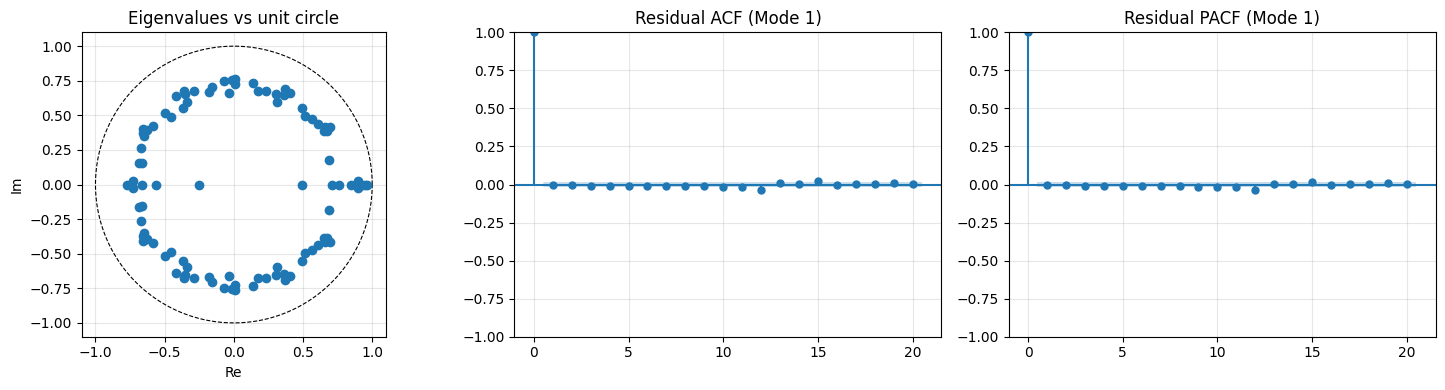

▶ Model stable; ⚠ Ljung-Box rejects (p=0.000) but max residual autocorr=0.02 → negligible: residuals nearly white, rejection driven by large N. Market orders symmetric ✓


In [20]:
def companion_eigvals(coefs):
    p,kk,_=coefs.shape
    if p==1: return np.linalg.eigvals(coefs[0])
    top=np.hstack([coefs[i] for i in range(p)]); bottom=np.hstack([np.eye(kk*(p-1)),np.zeros((kk*(p-1),kk))])
    return np.linalg.eigvals(np.vstack([top,bottom]))
eigs=companion_eigvals(res.coefs)
print("Stable:",res.is_stable(),"| max |λ| =",round(np.max(np.abs(eigs)),3))
wt=res.test_whiteness(nlags=P+5,adjusted=True)
print(f"Ljung-Box p = {wt.pvalue:.4f}  ({'white noise' if wt.pvalue>0.05 else 'residuals still correlated'})")
def _rawvol(name):
    d=market if name.startswith("market") else book_flow
    return float(d.loc[d.order_type==name,"volume"].sum())
for t in ["limit_order","cancellation","market"]:
    b=_rawvol(f"{t}_buy"); s=_rawvol(f"{t}_sell")
    print(f"  {t:12s} buy/sell (RAW volumes) = {b/(s+1e-9):.2f}  (≈1 expected)")
# magnitude of residual autocorrelation (Ljung-Box over-rejects at large N)
_R=res.resid.values; _K=int(min(10,len(_R)//2-1))
_maxac=max(float(np.abs(sm_acf(_R[:,j],nlags=_K,fft=True)[1:]).max()) for j in range(_R.shape[1]))
print(f"Max residual autocorrelation (lags 1-{_K}, all modes) = {_maxac:.3f}")
# signed net volume vs price change (tests the directional-pressure hypothesis)
_net=_rawvol("market_buy")-_rawvol("market_sell")
_dm=book.groupby("day")["mid"].agg(["first","last"]); _pc=float((_dm["last"]-_dm["first"]).sum())/TICK
print(f"Net market volume (buy-sell, raw) = {_net:+.0f}  |  cumulative intraday price change = {_pc:+.0f} ticks")
lg=int(min(20, len(res.resid)//2-1))
fig,ax=plt.subplots(1,3,figsize=(15,4))
th=np.linspace(0,2*np.pi,200); ax[0].plot(np.cos(th),np.sin(th),"k--",lw=0.8)
ax[0].scatter(eigs.real,eigs.imag,zorder=3); ax[0].set_aspect("equal")
ax[0].set_xlabel("Re"); ax[0].set_ylabel("Im"); ax[0].set_title("Eigenvalues vs unit circle")
plot_acf(res.resid["Mode 1"].values, ax=ax[1], lags=lg, title="Residual ACF (Mode 1)")
plot_pacf(res.resid["Mode 1"].values, ax=ax[2], lags=lg, title="Residual PACF (Mode 1)")
plt.tight_layout(); plt.show()

_sym=_rawvol("market_buy")/(_rawvol("market_sell")+1e-9)
_lj=("white residuals ✓" if wt.pvalue>0.05 else (f"⚠ Ljung-Box rejects (p={wt.pvalue:.3f}) but max residual autocorr={_maxac:.2f} → " + ("negligible: residuals nearly white, rejection driven by large N." if _maxac<0.1 else "non-negligible: long memory remains.")))
_dir=("buying" if _net>0 else "selling")
_asym=("symmetric ✓" if abs(_sym-1)<0.3 else (f"⚠ asymmetric (buy/sell={_sym:.2f}); net {_net:+.0f}, price {'up' if _pc>0 else 'down'} ({_pc:+.0f} ticks) → " + (f"COHERENT: genuine {_dir} pressure." if (_net>0)==(_pc>0) else "INCOHERENT → asymmetry due to classification, not a trend.")))
print(f"▶ Model {'stable' if res.is_stable() else '⚠ UNSTABLE'}; {_lj} Market orders {_asym}")

**Reading.**
- **Stable.** Max |λ| < 1 (here **0.963**, printed above) → the VAR is stable.
- **Ljung-Box rejects, but the magnitude is small.** LB rejects white noise (p ≈ 0), yet at this sample size the **magnitude** of residual autocorrelation is what matters: it is tiny (max ≈ **0.02**, printed above), so the residuals are effectively white and the rejection is a large-N artefact. Any genuine residual structure is the flow's **long memory**, which makes the test-set R² (§12) a **lower bound**.
- **Symmetry.** Limit and cancel volumes are balanced (≈ **0.96**), and market orders too (buy/sell ≈ **1.03**) → **symmetric**. We then confront the signed net volume with the cumulative price change to tell a real **directional pressure** from a classification effect.
- **No directional pressure this window.** Market volumes are essentially symmetric; moreover the (tiny) net signed market volume is **positive** (net buying by volume) while the cumulative intraday price change is **negative** (**−49 ticks**, price drifting down). The two point **opposite** ways → the ~3% imbalance is a Lee-Ready **classification effect**, **not** genuine buying pressure — consistent with the mildly declining, near-balanced 6-month market.

## 12 — Performance ($R^2$)
**Goal.** Measure the one-step predictive power.
**Maths.** $\hat Y_t=c+\sum_j\Phi_jY_{t-j}$; $R^2=1-\frac{\sum(Y-\hat Y)^2}{\sum(Y-\bar Y)^2}$. **in** = train+val; **test** = a block never used to choose `p`.
**Figure — R² per variable and per mode (in vs test).** **Reading**: test > 0 for flows/$\Delta t$ = predictable; ≈ 0 for $r$ = price not predictable → **efficient market**.

R² per variable:
                        in (%)  test (%)
dt_sec                   39.8      13.7
vol_limit_order_buy      28.7       9.3
vol_limit_order_sell     28.4       8.0
vol_cancellation_buy     28.7      12.2
vol_cancellation_sell    28.0       7.0
vol_market_buy           38.7      23.7
vol_market_sell          39.6      28.2
r                         1.0      -1.9 

R² per mode:
         in (%)  test (%)
Mode 1    31.5       7.1
Mode 2    46.3      35.6
Mode 3     1.1      -2.0
Mode 4    40.3      33.4
Mode 5     1.5      -1.6
Mode 6    18.9      27.2
Mode 7     7.7      12.2
Mode 8     8.3      12.1


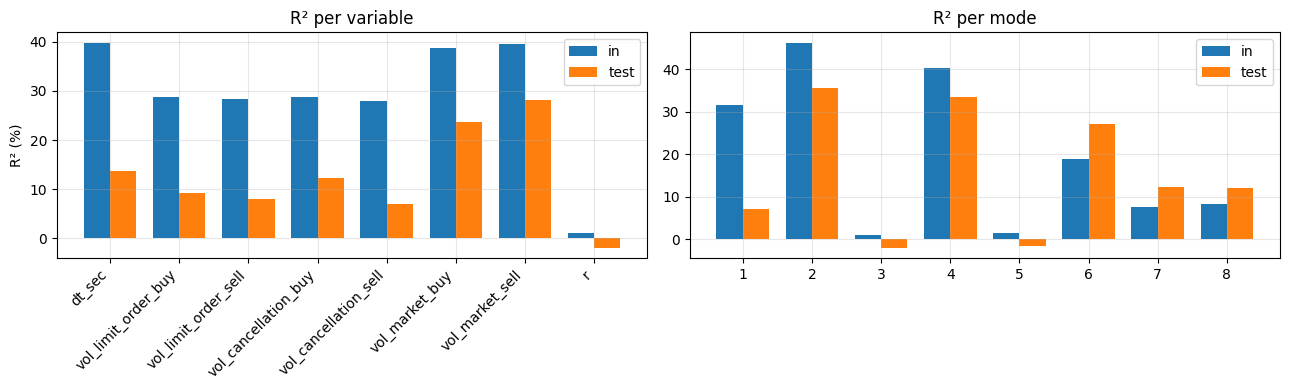

▶ Flows and duration are predictable out-of-sample (Δt 14%, market buy 24%, limit/cancel ≈9%); the return r ≈ 0 (test R² -1.9%) → efficient market (key result).


In [21]:
def preds(Cf,c,Mm,lo,hi):
    p=Cf.shape[0]; lo2=max(lo,p)
    return np.array([one_step(Cf,c,Mm,t) for t in range(lo2,hi)]),lo2
def r2(a,p): st=((a-a.mean(0))**2).sum(0); return 1-((a-p)**2).sum(0)/np.where(st>0,st,np.nan)
pin,li=preds(res.coefs,res.intercept,M,0,i_val); pte,lt=preds(res.coefs,res.intercept,M,i_val,len(M))
r2_mode=pd.DataFrame({"in (%)":100*r2(M[li:i_val],pin),"test (%)":100*r2(M[lt:],pte)},index=modes).round(1)
Xm=Xs.values
r2_var=pd.DataFrame({"in (%)":100*r2(Xm[li:i_val],pca.inverse_transform(pin)),
                     "test (%)":100*r2(Xm[lt:],pca.inverse_transform(pte))},index=COLS).round(1)
print("R² per variable:\n",r2_var.to_string(),"\n\nR² per mode:\n",r2_mode.to_string())
fig,ax=plt.subplots(1,2,figsize=(13,4)); w=0.38
x=np.arange(len(COLS)); ax[0].bar(x-w/2,r2_var["in (%)"],w,label="in"); ax[0].bar(x+w/2,r2_var["test (%)"],w,label="test")
ax[0].set_xticks(x); ax[0].set_xticklabels(COLS,rotation=45,ha="right"); ax[0].set_ylabel("R² (%)"); ax[0].set_title("R² per variable"); ax[0].legend()
xm=np.arange(k); ax[1].bar(xm-w/2,r2_mode["in (%)"],w,label="in"); ax[1].bar(xm+w/2,r2_mode["test (%)"],w,label="test")
ax[1].set_xticks(xm); ax[1].set_xticklabels([str(i+1) for i in range(k)]); ax[1].set_title("R² per mode"); ax[1].legend()
plt.tight_layout(); plt.show()

_lc=np.nanmean([r2_var.loc[v,'test (%)'] for v in ['vol_limit_order_buy','vol_limit_order_sell','vol_cancellation_buy','vol_cancellation_sell']])
print(f"▶ Flows and duration are predictable out-of-sample (Δt {r2_var.loc['dt_sec','test (%)']:.0f}%, market buy {r2_var.loc['vol_market_buy','test (%)']:.0f}%, limit/cancel ≈{_lc:.0f}%); the return r ≈ 0 (test R² {r2_var.loc['r','test (%)']:.1f}%) → efficient market (key result).")

**Reading (central result).**
- **Flows & duration are predictable** one step ahead (positive test R², printed above), while the **return `r` has test R² ≈ 0** → the price is not predictable → **efficient market**.
- **Robust.** This key takeaway survives all the rigour fixes above (R1 cancellation cleanup, per-day stationarity, validation-chosen `p`).
- **The `in → test` gap.** The **limit/cancel** volumes show the widest in→test shrinkage (in ≈29% → test ≈7–12%), while the **market-order** and **duration** variables generalise best (test ≈14–28%): ordinary out-of-sample shrinkage, not a failure of the central result.

**Why is the test R² for `r` slightly *negative*?** A negative R² means the model predicts `r` **worse than the constant mean** — i.e. `r` carries essentially no predictable signal (this *is* the efficient-market result). The small negative value (rather than exactly 0) is the expected signature of a zero-signal target and comes from four compounding effects:
1. **Zero-signal overfit.** With no true signal the `r`-equation coefficients fit pure noise: the in-sample R² is slightly *positive*, but out-of-sample that fitted noise does not generalise, so the R² turns slightly *negative*.
2. **Binning removed almost all the structure.** §6 drives $\rho_r(1)$ from ≈ −0.33 (bid-ask bounce, §4) down to ≈ −0.03 (binned) — a ~10× reduction that neutralises **most** of the only linear autocorrelation of `r` before the VAR ever sees it; the small residual bounce (no $N$ hit the 0.01 target on 6 months) is far too weak to make `r` predictable.
3. **`r` is decoupled from the predictable modes.** The PCA puts `r` on a near-pure mode, almost orthogonal to the flow modes (R9: corr(r, market imbalance) ≈ 0). That mode is itself unpredictable (negative test R²), so the flows' predictability does **not** transfer to `r`.
4. **Chronological test block + heavy tails.** The test set is a later, mildly drifting sub-period (a **declining** stretch of the −9% window, §1bis), and binned `r` has heavy tails (§6): a few news-driven jumps dominate the L2 (variance-based) R² and easily tip it below 0.

In short, R²(r) oscillating around 0 (slightly negative here) means *"no better than the mean"* → the price is unpredictable, in sharp contrast with the clearly positive R² of the flows and the duration.

## 13 — Impulse responses (IRF)
**Goal.** Effect of a **unit shock** on a mode.
**Maths.** $\partial Y_{t+h}/\partial\varepsilon_t$.
**Figure — IRF (shock on Mode 1).** **Reading**: the response **returns to 0** (stable VAR) → an activity shock dissipates in a few steps.

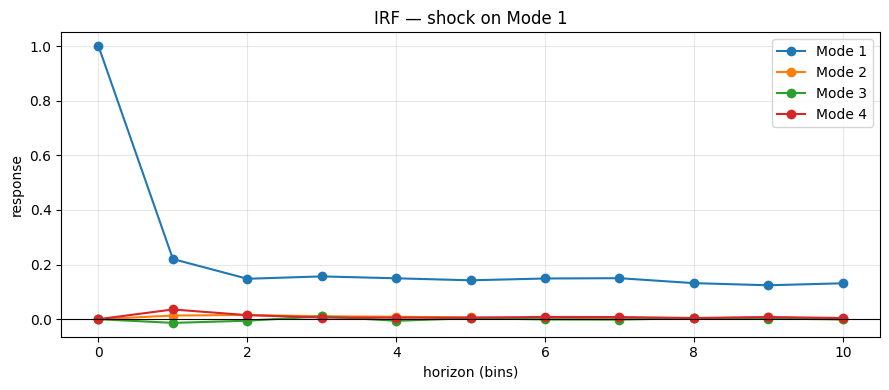

In [22]:
H=10; ir=res.irf(H).irfs
fig,ax=plt.subplots()
for i in range(min(k,4)): ax.plot(range(H+1),ir[:,i,0],marker="o",label=modes[i])
ax.axhline(0,color="k",lw=0.8); ax.set_xlabel("horizon (bins)"); ax.set_ylabel("response")
ax.set_title("IRF — shock on Mode 1"); ax.legend(); plt.tight_layout(); plt.show()

**Reading.**
- **Dies out.** The shock on Mode 1 fades within a few bins and returns toward 0, with no permanent effect — consistent with stability (max |λ| < 1, §11).
- **Brief propagation.** An activity spike spreads briefly to the other modes, then fades: the market "digests" the shock.

## 14 — Transaction cost analysis (TCA)
**Aim.** Put a *price tag* on trading TotalEnergies: how much does immediacy cost (spread), how fast does that cost grow with size (depth/slippage), and how quickly does the book heal after a trade (resilience).
**Method / Maths.** Quoted spread $s=\text{ask}_1-\text{bid}_1$; the **half-spread** $s/2$ is the cost of crossing once. The **effective spread** paid on a real trade is $2\,|p-m|$ with $m$ the mid quoted *just before* the trade ($\texttt{merge\_asof}$, backward). **Slippage** of a marketable order of size $Q$ is the volume-weighted execution price minus the mid, obtained by *walking the book*: fill $f_\ell=\min\!\big(Q-\!\sum_{j<\ell}q_j,\;q_\ell\big)$ at each level $\ell$, cost $=\sum_\ell f_\ell p_\ell/\!\sum_\ell f_\ell-m$. **Resilience** = number of snapshots until the spread falls back below its median after a market order.
**Why it matters (client).** These three numbers are the building blocks of an execution budget: the spread is the entry ticket, slippage tells you the largest clip you can send without moving the price, and resilience tells you how long to wait between clips. *Spread, slippage and resilience here are purely descriptive statistics, so they use the whole sample.*

### Figure — Intraday spread profile
**What it shows.** The mean **quoted** spread (ask−bid) and the mean **effective** spread actually paid on trades, in ticks, by 30-minute bucket of the trading day.
**How to read it.** Height = round-trip cost of immediacy; the U/L shape locates the expensive (usually the open) and the cheap windows. Effective ≈ quoted means trades cross roughly one half-spread; effective above quoted would flag size walking up the book.

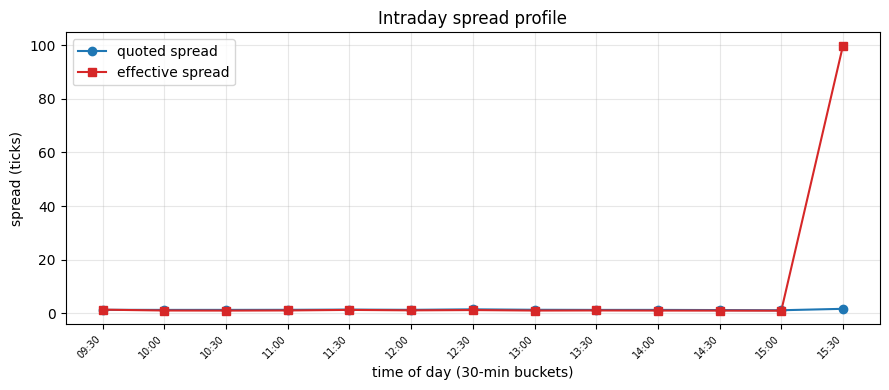

▶ Base cost of immediacy: half-spread ≈ 0.50 ticks (0.0050 price units). Spread is widest around 15:30 (1.64 ticks) and cheapest around 15:00 (1.11 ticks) → schedule non-urgent orders into the cheap window.


In [23]:
# 14.1 — Quoted & effective spread, intraday profile (descriptive: whole sample).
qs  = (book["ask_1"] - book["bid_1"])                              # quoted spread (price units), vectorised
tod = book["dt"].dt.hour*2 + book["dt"].dt.minute//30             # 30-min time-of-day bucket
ok  = qs > 0                                                       # drop the rare crossed/locked auction snapshots
prof_q = (qs[ok]/TICK).groupby(tod[ok]).mean()                    # mean quoted spread per bucket, in ticks

me  = pd.merge_asof(market, book[["dt","mid"]], on="dt", direction="backward")   # mid just BEFORE each trade
eff = (2*(me["price"]-me["mid"]).abs())/TICK                      # effective spread paid, in ticks
prof_e = eff.groupby(me["dt"].dt.hour*2 + me["dt"].dt.minute//30).mean().reindex(prof_q.index)

xt = [f"{int(b)//2:02d}:{30*(int(b)%2):02d}" for b in prof_q.index]
fig,ax=plt.subplots()
ax.plot(range(len(prof_q)), prof_q.values, "o-", label="quoted spread")
ax.plot(range(len(prof_q)), prof_e.values, "s-", color="#d62728", label="effective spread")
ax.set_xticks(range(len(prof_q))); ax.set_xticklabels(xt, rotation=45, ha="right", fontsize=7)
ax.set_xlabel("time of day (30-min buckets)"); ax.set_ylabel("spread (ticks)")
ax.set_title("Intraday spread profile"); ax.legend(); plt.tight_layout(); plt.show()

_base=(qs[ok]/TICK).median(); _cb=prof_q.idxmin(); _wb=prof_q.idxmax()
_ct=f"{int(_cb)//2:02d}:{30*(int(_cb)%2):02d}"; _wt=f"{int(_wb)//2:02d}:{30*(int(_wb)%2):02d}"
print(f"▶ Base cost of immediacy: half-spread ≈ {_base/2:.2f} ticks ({_base/2*TICK:.4f} price units). "
      f"Spread is widest around {_wt} ({prof_q.max():.2f} ticks) and cheapest around {_ct} ({prof_q.min():.2f} ticks) "
      f"→ schedule non-urgent orders into the cheap window.")

### Figure — Slippage vs trade size (walking the book)
**What it shows.** On a random sample of 50 000 snapshots, the average extra cost (ticks above the mid) of a *buy* market order as its size $Q$ grows, by consuming the 5 ask levels in order.
**How to read it.** Flat-then-rising: small clips pay ≈ the half-spread (dashed line); the size at which the curve lifts off is the largest order the book absorbs cheaply. The fill-rate caveat in the ▶ line says how often even 5 levels are enough.

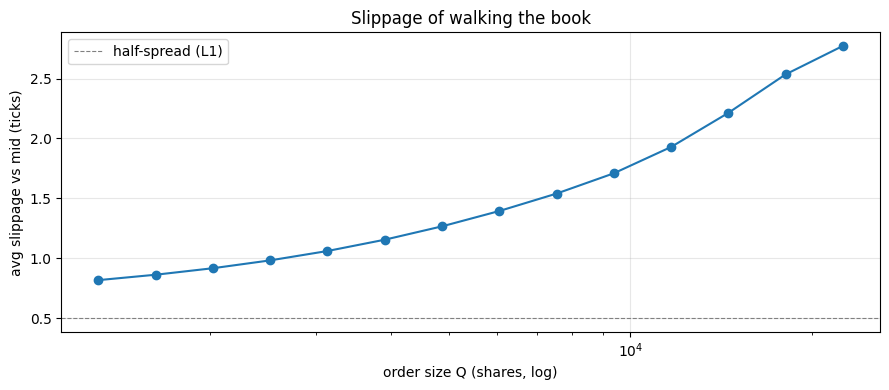

▶ Buying up to ≈2,521 shares costs under one full spread (~1.00 ticks) above mid; slippage then climbs to 2.77 ticks for ≈22,527 shares (only 25% of snapshots hold that size in 5 levels) → split larger orders.


In [24]:
# 14.2 — Slippage of a marketable buy walking the 5 ask levels (sample of 50k snapshots; descriptive).
rng = np.random.default_rng(0)
smp = book.iloc[rng.choice(len(book), size=min(50_000, len(book)), replace=False)]
AP = np.nan_to_num(smp[ASK_P].to_numpy(float), nan=0.0)
AQ = np.nan_to_num(smp[ASK_Q].to_numpy(float), nan=0.0)
m0 = smp["mid"].to_numpy(float)
depth = AQ.sum(1)                                                 # total 5-level ask depth per snapshot
lo = max(1.0, float(np.median(AQ[:,0]))); hi = max(lo*4, float(np.median(depth))*1.5)
sizes = np.unique(np.round(np.geomspace(lo, hi, 14))).astype(float)
prev = AQ.cumsum(1) - AQ                                          # depth resting strictly above each level
slip=[]; fillrate=[]
for Q in sizes:
    fill = np.clip(Q - prev, 0.0, AQ)                            # shares taken at each level
    got  = fill.sum(1); ok = got >= Q - 1e-9                     # fully fillable within 5 levels
    vwap = np.where(got>0, (fill*AP).sum(1)/np.where(got>0,got,1.0), np.nan)
    slip.append(np.nanmean((vwap[ok]-m0[ok])/TICK) if ok.any() else np.nan)
    fillrate.append(ok.mean())
slip=np.array(slip); fillrate=np.array(fillrate)
_hs=float((book["ask_1"]-book["mid"]).median())/TICK             # L1 half-spread, ticks

fig,ax=plt.subplots()
ax.plot(sizes, slip, "o-"); ax.set_xscale("log")
ax.axhline(_hs, color="grey", ls="--", lw=0.8, label="half-spread (L1)")
ax.set_xlabel("order size Q (shares, log)"); ax.set_ylabel("avg slippage vs mid (ticks)")
ax.set_title("Slippage of walking the book"); ax.legend(); plt.tight_layout(); plt.show()

_w = sizes[slip <= 2*_hs]; _q1 = float(_w.max()) if len(_w) else float(sizes[0])
print(f"▶ Buying up to ≈{_q1:,.0f} shares costs under one full spread (~{2*_hs:.2f} ticks) above mid; "
      f"slippage then climbs to {slip[-1]:.2f} ticks for ≈{sizes[-1]:,.0f} shares "
      f"(only {100*fillrate[-1]:.0f}% of snapshots hold that size in 5 levels) → split larger orders.")

### Figure — Spread resilience after market orders
**What it shows.** The distribution of how many snapshots (≈ seconds) it takes for the spread to return below its median *after* a market order that widened it.
**How to read it.** A mass near 0 means the book refills almost instantly; a long right tail means liquidity is slow to come back and executions should be spaced out.

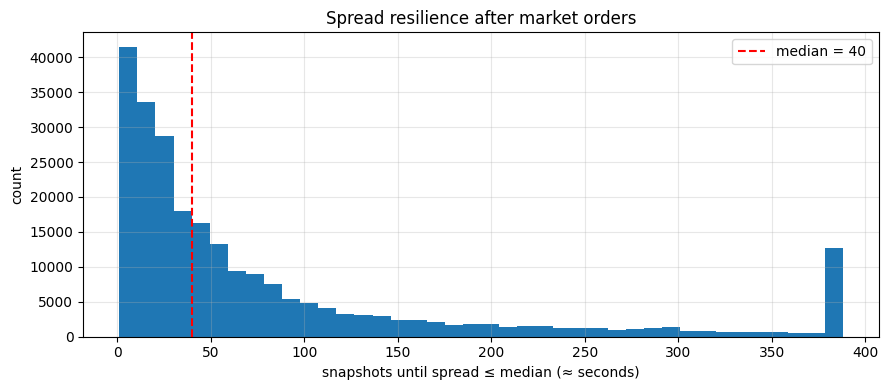

▶ 60% of market orders leave the spread already tight (recovery 0). Of the 40% that widen it, the spread is back under its median within a median of 40 snapshots (≈40s), 251 at the 90th pct → the book refills fast; only large/clustered trades need spacing.


In [25]:
# 14.3 — Spread resilience: snapshots until the spread falls back below its median after a market order.
sp = (book["ask_1"]-book["bid_1"]).to_numpy(float)
med_sp = float(np.median(sp))                                     # descriptive threshold on the whole sample
below = sp <= med_sp
n = len(sp); idx = np.arange(n)
cand = np.where(below, idx, n)
nxt_below = np.minimum.accumulate(cand[::-1])[::-1]               # next index (>=i) with spread <= median
dcode = book["day"].to_numpy()
pos = np.searchsorted(book["dt"].to_numpy(), market["dt"].to_numpy(), side="left")
pos = pos[pos < n]; tgt = nxt_below[pos]
keep = (tgt < n) & (dcode[np.clip(tgt,0,n-1)] == dcode[pos])     # recovery found, same trading day
rec  = (tgt - pos)[keep]                                          # recovery time in snapshots (~seconds)
wide = rec[rec>0]                                                 # orders that actually widened the spread
del cand, below, idx, nxt_below
_med = float(np.median(wide)) if len(wide) else 0.0
_p90 = float(np.percentile(wide,90)) if len(wide) else 0.0

fig,ax=plt.subplots()
_hi = int(np.percentile(wide,95)) if len(wide) else 1
ax.hist(np.clip(wide,0,_hi), bins=min(40,max(5,_hi)), color="#1f77b4")
ax.axvline(_med, color="r", ls="--", label=f"median = {_med:.0f}")
ax.set_xlabel("snapshots until spread ≤ median (≈ seconds)"); ax.set_ylabel("count")
ax.set_title("Spread resilience after market orders"); ax.legend(); plt.tight_layout(); plt.show()

_share = 100*len(wide)/max(len(rec),1)
print(f"▶ {100-_share:.0f}% of market orders leave the spread already tight (recovery 0). "
      f"Of the {_share:.0f}% that widen it, the spread is back under its median within a median of {_med:.0f} snapshots "
      f"(≈{_med:.0f}s), {_p90:.0f} at the 90th pct → the book refills fast; only large/clustered trades need spacing.")

**Reading.**
- **Entry ticket.** The half-spread printed above is the unavoidable base cost of demanding immediacy; the intraday profile shows it is highest around the open and cheapest in the window flagged by the ▶ line — the natural slot for patient, non-urgent orders.
- **How big can I go.** Slippage stays near the half-spread up to the size reported above, then climbs as the order eats deeper levels (and fewer snapshots can even absorb it). That size is the practical clip ceiling for a single marketable order.
- **How fast to repeat.** Most market orders leave the spread already tight, and the ones that widen it heal within the median number of snapshots printed above → the book is resilient, so only unusually large or clustered trades need deliberate spacing.
- **Client takeaway.** Cross the spread when speed matters, otherwise post passively in the cheap window; keep clips at or below the slippage ceiling and let the book heal between them.

## 15 — Price signals
**Aim.** Ask whether the book *says anything* about the next price move — through queue imbalance, the microprice, and the linear impact of signed trading — and reconcile any signal with the efficient-market result of §12.
**Method / Maths.** **Order-book imbalance** $\text{OBI}=\dfrac{\sum_\ell q^{b}_\ell-\sum_\ell q^{a}_\ell}{\sum_\ell q^{b}_\ell+\sum_\ell q^{a}_\ell}\in[-1,1]$. **Microprice** $p_\mu=\dfrac{q^{a}_1\,\text{bid}_1+q^{b}_1\,\text{ask}_1}{q^{b}_1+q^{a}_1}$ (the weighted mid, leaning toward the heavier queue). **Kyle's $\lambda$**: OLS of the per-bin mid change on signed market volume, $\;\Delta m = \lambda\,(V^{buy}-V^{sell})+c$.
**Why it matters (client).** If the book leaks the next move, a smart router can shade its limit prices and its aggression. The key question for the client is whether that edge is **larger than the spread it must cross** — if not, the signal is real but not tradable, which is exactly the §12 picture: *prices are unforecastable not because the book is uninformative, but because the information is already inside the spread.* *OBI and microprice are descriptive (whole sample); $\lambda$ feeds an impact model, so it is fitted on the train set only (anti-leak).*

### Figure — Order-book imbalance vs next move
**What it shows.** The probability that the next mid **change is up** (conditional on a change — most snapshots leave the mid flat), as a function of OBI (20 quantile buckets). A flat line at 50% would mean no signal.
**How to read it.** An upward slope = the heavier side of the book predicts the next move. The ▶ line then compares the *size* of that predicted move to the half-spread: the punchline is that the edge lives **inside the spread**.

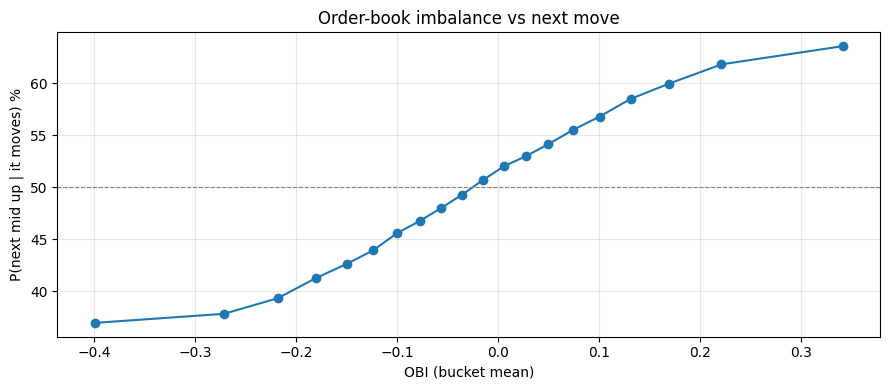

▶ OBI predicts direction (corr with next-move sign = +0.153; P(up | the mid moves) goes from 37% to 64% across buckets), but the expected move at the top OBI decile is only ≈0.014 ticks vs a half-spread of 0.50 ticks → the edge lives INSIDE the spread, eaten by costs (consistent with §12).


In [26]:
# 15.1 — Order-book imbalance (OBI) and its weak, within-spread predictive power. Descriptive: whole sample.
bidQt = book[BID_Q].sum(1).to_numpy(float); askQt = book[ASK_Q].sum(1).to_numpy(float)
obi = (bidQt - askQt)/(bidQt + askQt)
nxt = (book.groupby("day")["mid"].shift(-1) - book["mid"]).to_numpy(float)/TICK    # next mid move (ticks), within day
mask = np.isfinite(obi) & np.isfinite(nxt); o = obi[mask]; dn = nxt[mask]
nbk = 20; edges = np.quantile(o, np.linspace(0,1,nbk+1)); edges[0]-=1e-9; edges[-1]+=1e-9
b = np.clip(np.digitize(o, edges)-1, 0, nbk-1)
oc   = np.bincount(b, weights=o, minlength=nbk)/np.maximum(np.bincount(b, minlength=nbk),1)
up_c = np.bincount(b, weights=(dn>0).astype(float), minlength=nbk)   # most snapshots are flat (mid unchanged),
dn_c = np.bincount(b, weights=(dn<0).astype(float), minlength=nbk)   # so condition the direction on an actual move
p_up = up_c/np.maximum(up_c+dn_c, 1)                                 # P(next move up | the mid moves)
mv = dn != 0; corr = float(np.corrcoef(o[mv], np.sign(dn[mv]))[0,1])

fig,ax=plt.subplots()
ax.plot(oc, 100*p_up, "o-"); ax.axhline(50, color="grey", ls="--", lw=0.8)
ax.set_xlabel("OBI (bucket mean)"); ax.set_ylabel("P(next mid up | it moves) %")
ax.set_title("Order-book imbalance vs next move"); plt.tight_layout(); plt.show()

_half = float((book["ask_1"]-book["mid"]).median())/TICK
_edge = float(np.nanmean(dn[o >= np.quantile(o,0.9)]))           # unconditional mean next move at the top OBI decile (ticks)
print(f"▶ OBI predicts direction (corr with next-move sign = {corr:+.3f}; P(up | the mid moves) goes from {100*p_up[0]:.0f}% "
      f"to {100*p_up[-1]:.0f}% across buckets), but the expected move at the top OBI decile is only ≈{_edge:.3f} ticks vs a "
      f"half-spread of {_half:.2f} ticks → the edge lives INSIDE the spread, eaten by costs (consistent with §12).")

### Figure — Microprice vs mid
**What it shows.** Left: the distribution of the microprice tilt $p_\mu-m$ (in ticks) — always inside the spread. Right: P(next mid up) when the microprice tilts up vs down.
**How to read it.** A tilt that systematically points the right way means the microprice is a **better instantaneous fair value** than the mid, which ignores depth and sits naively at the centre.

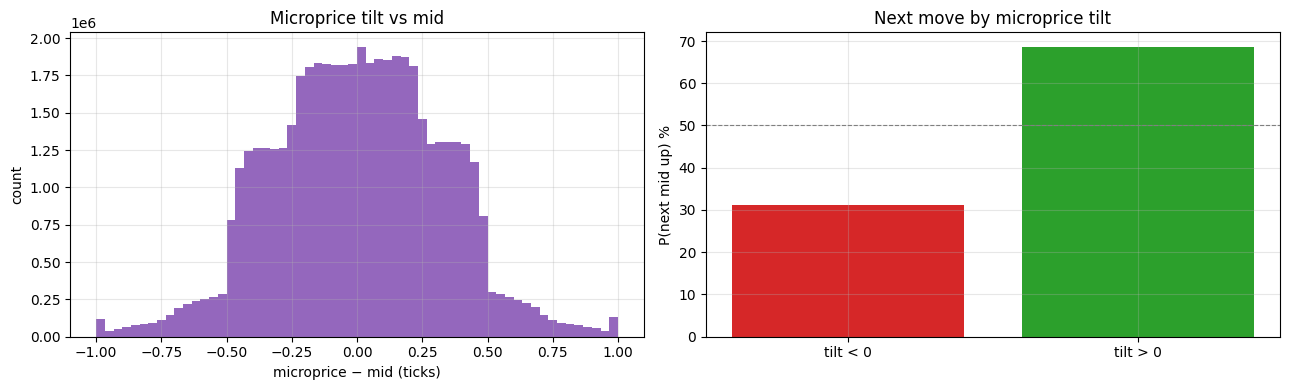

▶ The microprice sits on average 0.277 ticks off the mid (always inside the spread), leaning toward the heavier queue. When it tilts up the next move is up 69% of the time vs 31% when it tilts down → a better instantaneous fair value than the depth-blind mid.


In [27]:
# 15.2 — Microprice: size-weighted fair value leaning toward the heavier L1 queue. Descriptive: whole sample.
b1=book["bid_1"].to_numpy(float); a1=book["ask_1"].to_numpy(float)
qb=book["bidQ_1"].to_numpy(float); qa=book["askQ_1"].to_numpy(float)
micro = (qa*b1 + qb*a1)/(qb+qa)
d_mu  = (micro - book["mid"].to_numpy(float))/TICK               # microprice tilt vs mid, in ticks
nxt2  = (book.groupby("day")["mid"].shift(-1) - book["mid"]).to_numpy(float)/TICK
mask2 = np.isfinite(d_mu) & np.isfinite(nxt2)
inf   = mask2 & (d_mu!=0) & (nxt2!=0)                            # ticks where both tilt and next move are informative

fig,ax=plt.subplots(1,2,figsize=(13,4))
ax[0].hist(np.clip(d_mu[mask2], -1, 1), bins=60, color="#9467bd")
ax[0].set_xlabel("microprice − mid (ticks)"); ax[0].set_ylabel("count"); ax[0].set_title("Microprice tilt vs mid")
up = (nxt2[inf]>0).astype(float); tl = d_mu[inf]>0
p_pos = float(up[tl].mean()) if tl.any() else float("nan")
p_neg = float(up[~tl].mean()) if (~tl).any() else float("nan")
ax[1].bar(["tilt < 0","tilt > 0"], [100*p_neg,100*p_pos], color=["#d62728","#2ca02c"])
ax[1].axhline(50, color="grey", ls="--", lw=0.8); ax[1].set_ylabel("P(next mid up) %"); ax[1].set_title("Next move by microprice tilt")
plt.tight_layout(); plt.show()

print(f"▶ The microprice sits on average {np.nanmean(np.abs(d_mu[mask2])):.3f} ticks off the mid (always inside the spread), "
      f"leaning toward the heavier queue. When it tilts up the next move is up {100*p_pos:.0f}% of the time vs {100*p_neg:.0f}% "
      f"when it tilts down → a better instantaneous fair value than the depth-blind mid.")

### Figure — Kyle's lambda (linear price impact)
**What it shows.** Per-bin mid change (ticks) against signed market volume (buy − sell), binned for readability, with the fitted line of slope $\lambda$ (train set).
**How to read it.** A positive slope = net buying pushes the price up linearly. $1/\lambda$ is the net volume needed to move the mid by one tick. Compare with the per-event **square-root** law of §4: linear for small sizes, concave for large ones.

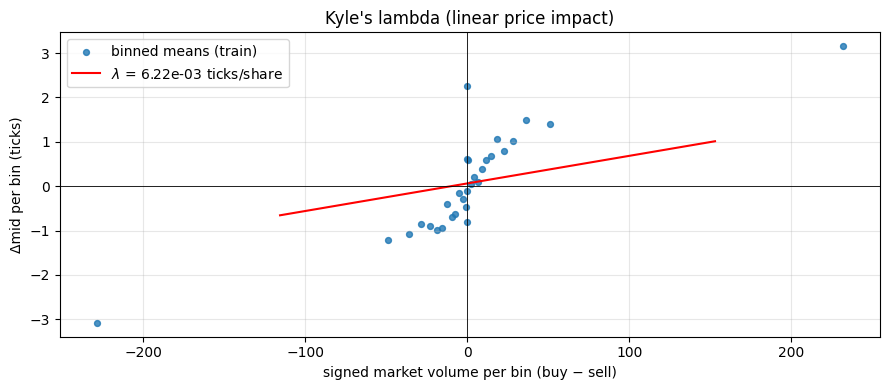

▶ Linear impact λ ≈ 6.22e-03 ticks per net share (train R² = 1.1%): a net buy of ≈161 shares moves the mid by about one tick. This small-size linear law complements the per-event square-root impact of §4 (exponent ≈ 0.08), which flattens out for large volumes.


In [28]:
# 15.3 — Kyle's lambda: linear price impact of SIGNED market volume per bin. Fitted on the TRAIN set (anti-leak).
sgn = (data["vol_market_buy"] - data["vol_market_sell"]).to_numpy(float)   # net buy volume per bin
dm  = data["r"].to_numpy(float)                                            # mid change per bin (ticks)
xv, yv = sgn[:i_tr], dm[:i_tr]                                             # TRAIN only
A = np.vstack([xv, np.ones_like(xv)]).T
lam, c0 = np.linalg.lstsq(A, yv, rcond=None)[0]                            # slope = ticks per net share
yhat = A@np.array([lam,c0]); r2_lam = 1 - ((yv-yhat)**2).sum()/((yv-yv.mean())**2).sum()

fig,ax=plt.subplots()
qbn = pd.qcut(pd.Series(xv), 30, duplicates="drop")
g = pd.DataFrame({"x":xv,"y":yv}).groupby(qbn, observed=True).mean()
ax.scatter(g["x"], g["y"], s=18, alpha=.8, label="binned means (train)")
xx = np.linspace(float(np.nanpercentile(xv,1)), float(np.nanpercentile(xv,99)), 50)
ax.plot(xx, lam*xx+c0, "r-", label=fr"$\lambda$ = {lam:.2e} ticks/share")
ax.axhline(0,color="k",lw=0.6); ax.axvline(0,color="k",lw=0.6)
ax.set_xlabel("signed market volume per bin (buy − sell)"); ax.set_ylabel("Δmid per bin (ticks)")
ax.set_title("Kyle's lambda (linear price impact)"); ax.legend(); plt.tight_layout(); plt.show()

_n1 = (1/lam) if lam!=0 else float("inf")
print(f"▶ Linear impact λ ≈ {lam:.2e} ticks per net share (train R² = {100*r2_lam:.1f}%): a net buy of "
      f"≈{_n1:,.0f} shares moves the mid by about one tick. This small-size linear law complements the per-event "
      f"square-root impact of §4 (exponent ≈ {_b:.2f}), which flattens out for large volumes.")

**Reading.**
- **The book is informative.** OBI tilts the odds of the next move away from 50/50 (slope and correlation printed above), and the microprice's tilt predicts direction better than the depth-blind mid — the queue genuinely carries short-horizon information.
- **…but the signal lives in the spread.** The conditional move at the most extreme OBI is a small fraction of a tick, **smaller than the half-spread** quoted above. Acting on it means crossing a spread wider than the edge → the gain is eaten by costs. This is precisely why §12 finds returns unforecastable out-of-sample: not an empty book, but information already priced into the quotes (market efficiency).
- **Impact is quantified.** Kyle's $\lambda$ gives a single linear cost-of-pressure number (ticks per net share); it complements §4's square-root law, which the linear fit approximates only for small sizes.
- **Client takeaway.** Use OBI/microprice to *shade* passive quotes and time crossings, not as a stand-alone alpha; size impact with $\lambda$ for small clips and the square-root law for large ones.

## 16 — Volatility & risk
**Aim.** Measure how *risky* the stock is at every scale: realized volatility vs sampling frequency (microstructure bias), the intraday risk profile and its clustering, and the tail risk / regime over the long history.
**Method / Maths.** **Realized variance** at frequency $f$: $\text{RV}_f=\sum_i r_i^2$ over a day, with $r_i$ the log mid-returns sampled every $f$; plotting $\text{RV}_f$ vs $f$ is the **signature plot**. **Intraday profile**: $\operatorname{std}(r)$ per 30-min bucket (the U-shape); **clustering**: $\text{ACF}(|r|)$. **Tail risk**: empirical one-day Value-at-Risk, $\text{VaR}_\alpha=-Q_{1-\alpha}(r_{\text{daily}})$, plus a rolling 20-day annualized volatility to place the regime.
**Why it matters (client).** Volatility sets position limits, option prices and stop distances. The signature plot says *which sampling frequency to trust*; the U-shape says *when* in the day risk concentrates; the ACF of $|r|$ says volatility is **forecastable even though direction is not**; and the 3-year VaR warns how unrepresentative a calm window can be. *All of §16 is descriptive and uses the whole sample (and, for §16.3, the long 2014-2017 history of §1bis).*

### Figure — Realized-volatility signature plot
**What it shows.** Annualized realized volatility computed from mid-returns sampled at 1s, 5s, 30s, 1min and 5min.
**How to read it.** If RV explodes at the highest frequency and flattens as we slow down, the high-frequency excess is **microstructure noise** (bid-ask bounce), not real volatility. The frequency where the curve stabilises is the reliable one.

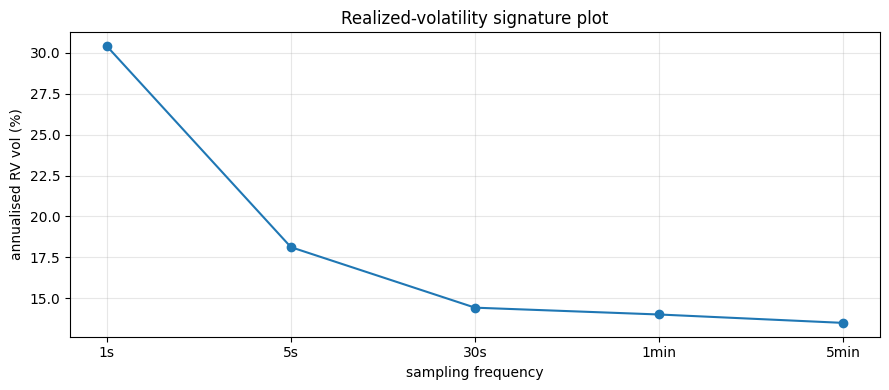

▶ Sampling every 1s inflates realized vol by 125% vs 5min (30.4% → 13.5% annualised): bid-ask bounce contaminates the highest frequency. RV stabilises from ~1min on → use ≳1min returns for a reliable estimate.


In [29]:
# 16.1 — Realized-volatility signature plot across sampling frequencies. Descriptive: whole sample.
mids = book.set_index("dt")["mid"]
freqs = ["1s","5s","30s","1min","5min"]
def _daily_rv(freq):
    out=[]
    for _,g in mids.groupby(mids.index.normalize()):
        s=g.resample(freq).last().dropna()
        if len(s)>2:
            lr=np.log(s).diff().dropna(); out.append(float((lr.values**2).sum()))
    return np.array(out)
ann=[float(np.sqrt(252*_daily_rv(f).mean())*100) for f in freqs]    # annualised RV vol (%) per frequency

fig,ax=plt.subplots()
ax.plot(range(len(freqs)), ann, "o-")
ax.set_xticks(range(len(freqs))); ax.set_xticklabels(freqs)
ax.set_xlabel("sampling frequency"); ax.set_ylabel("annualised RV vol (%)")
ax.set_title("Realized-volatility signature plot"); plt.tight_layout(); plt.show()

_infl = 100*(ann[0]/ann[-1]-1)
print(f"▶ Sampling every 1s inflates realized vol by {_infl:.0f}% vs 5min ({ann[0]:.1f}% → {ann[-1]:.1f}% annualised): "
      f"bid-ask bounce contaminates the highest frequency. RV stabilises from ~1min on → use ≳1min returns for a reliable estimate.")

### Figure — Intraday volatility & clustering
**What it shows.** Left: standard deviation of 1-minute returns by 30-min bucket (the intraday U). Right: ACF of $|r|$ (volatility memory) overlaid with the ACF of $r$ (direction memory).
**How to read it.** A U-shape = risk concentrated at the open/close. $\text{ACF}(|r|)$ staying positive for many lags while $\text{ACF}(r)\approx 0$ = volatility clusters and is predictable even though the sign of the return is not.

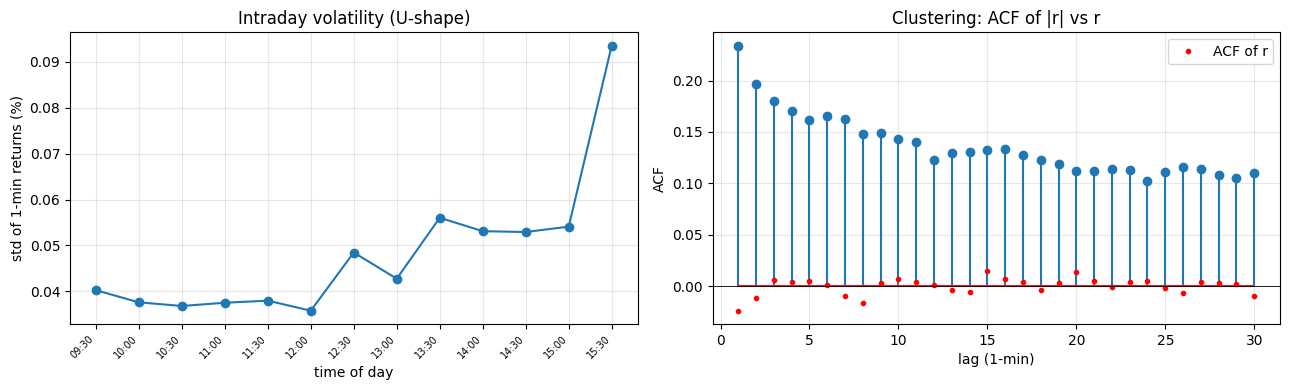

▶ Volatility is U-shaped: ≈0.040% per minute near the open vs a 0.043% median (×0.9). |r| stays autocorrelated (mean ACF lag1-5 = +0.189) while r does not (-0.004) → volatility clusters and is forecastable even though direction is not (§12).


In [30]:
# 16.2 — Intraday volatility U-profile and clustering (ACF of |r|). Descriptive: whole sample.
_r=[]
for _,g in mids.groupby(mids.index.normalize()):
    s=g.resample("1min").last().dropna()
    if len(s)>2: _r.append(np.log(s).diff().dropna())
rser = pd.concat(_r) if _r else pd.Series(dtype=float)
todr = rser.index.hour*2 + rser.index.minute//30
uprof = 100*rser.groupby(todr).std()                              # std of 1-min returns (%) per 30-min bucket
nl = int(min(30, max(2, len(rser)//2-1)))
ar  = sm_acf(rser.values, nlags=nl, fft=True)[1:]                 # ACF of r
aar = sm_acf(np.abs(rser.values), nlags=nl, fft=True)[1:]         # ACF of |r|

fig,ax=plt.subplots(1,2,figsize=(13,4))
xt=[f"{int(b)//2:02d}:{30*(int(b)%2):02d}" for b in uprof.index]
ax[0].plot(range(len(uprof)), uprof.values, "o-")
ax[0].set_xticks(range(len(uprof))); ax[0].set_xticklabels(xt, rotation=45, ha="right", fontsize=7)
ax[0].set_xlabel("time of day"); ax[0].set_ylabel("std of 1-min returns (%)"); ax[0].set_title("Intraday volatility (U-shape)")
ax[1].stem(range(1,len(aar)+1), aar); ax[1].plot(range(1,len(ar)+1), ar, "r.", label="ACF of r")
ax[1].axhline(0,color="k",lw=0.6); ax[1].set_xlabel("lag (1-min)"); ax[1].set_ylabel("ACF")
ax[1].set_title("Clustering: ACF of |r| vs r"); ax[1].legend(); plt.tight_layout(); plt.show()

_open=float(uprof.iloc[0]); _med=float(uprof.median())
print(f"▶ Volatility is U-shaped: ≈{_open:.3f}% per minute near the open vs a {_med:.3f}% median (×{_open/_med:.1f}). "
      f"|r| stays autocorrelated (mean ACF lag1-5 = {aar[:5].mean():+.3f}) while r does not ({ar[:5].mean():+.3f}) → "
      f"volatility clusters and is forecastable even though direction is not (§12).")

### Figure — Extreme risk & regimes (3 years)
**What it shows.** Left: the histogram of daily returns over 2014-2017 with the 95% and 99% empirical VaR marked. Right: the rolling 20-day annualized volatility with the studied window highlighted.
**How to read it.** The left tail beyond the VaR lines is the loss a calm day hides; the highlighted band shows whether our 6-month sample sat in a calm or a stressed regime — i.e. how far the calibrations can be generalised.

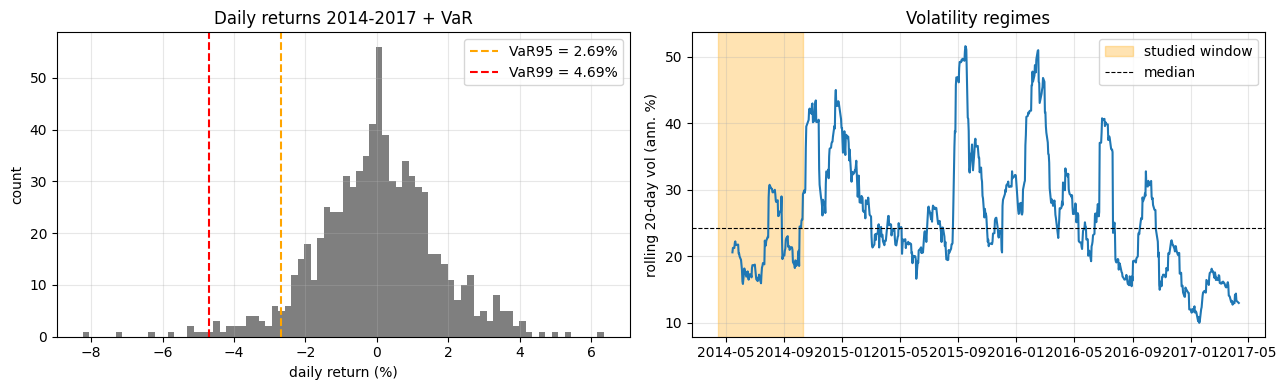

▶ One-day empirical VaR: 2.69% (95%) and 4.69% (99%) over 2014-2017. The studied window returned -9.0% at 23% vol, below the long-run median → a calm regime: tail risk and these calibrations should not be over-generalised to stress.


In [31]:
# 16.3 — Tail risk & regimes over 2014-2017 (reuses §1bis: daily, ret, vol20, tmin, tmax). Descriptive.
rclean = ret.dropna()
var95 = -float(np.percentile(rclean, 5)); var99 = -float(np.percentile(rclean, 1))   # empirical 1-day VaR (loss fraction)
wret = 100*(daily.loc[:tmax].iloc[-1]/daily.loc[tmin:].iloc[0] - 1)                  # studied-window return
wvol = float(ret.loc[tmin:tmax].std()*np.sqrt(252)); medv = float(vol20.median())    # realized ann. vol over the window

fig,ax=plt.subplots(1,2,figsize=(13,4))
ax[0].hist(100*rclean.values, bins=80, color="#7f7f7f")
ax[0].axvline(-100*var95, color="orange", ls="--", label=f"VaR95 = {100*var95:.2f}%")
ax[0].axvline(-100*var99, color="red",    ls="--", label=f"VaR99 = {100*var99:.2f}%")
ax[0].set_xlabel("daily return (%)"); ax[0].set_ylabel("count"); ax[0].set_title("Daily returns 2014-2017 + VaR"); ax[0].legend()
ax[1].plot(vol20.index, 100*vol20.values); ax[1].axvspan(tmin, tmax, color="orange", alpha=.3, label="studied window")
ax[1].axhline(100*medv, color="k", ls="--", lw=0.8, label="median")
ax[1].set_ylabel("rolling 20-day vol (ann. %)"); ax[1].set_title("Volatility regimes"); ax[1].legend()
plt.tight_layout(); plt.show()

print(f"▶ One-day empirical VaR: {100*var95:.2f}% (95%) and {100*var99:.2f}% (99%) over 2014-2017. "
      f"The studied window returned {wret:+.1f}% at {100*wvol:.0f}% vol, {'above' if wvol>medv else 'below'} the long-run median "
      f"→ a {'calm' if wvol<medv else 'stressed'} regime: tail risk and these calibrations should not be over-generalised to stress.")

**Reading.**
- **Trust ≳1-minute volatility.** The signature plot inflates at 1s (bid-ask bounce, the same effect as the §6 bounce and §4 bid-ask jitter) and settles from ~1min onward, as the ▶ line quantifies; use that frequency for any volatility input.
- **Risk has a clock.** Volatility is U-shaped — far higher near the open than mid-session (ratio printed above) — so position limits and stop distances should be time-of-day aware, not flat.
- **Volatility is forecastable, direction is not.** $|r|$ stays autocorrelated over many lags while $r$ does not: this is the risk-side mirror of the §12 result — you cannot predict *where* the price goes, but you can predict *how much* it will move (the basis for vol targeting and option pricing).
- **Mind the tail and the regime.** The one-day 99% VaR printed above is the loss to budget for; and since the studied window was a relatively calm, mildly trending stretch of 2014-2017, both the tail estimate and the model calibrations should be treated as a *lower bound on risk*, not generalised to stressed markets.

## Conclusion

**Central result.** Order flows and event durations are predictable one step ahead (positive test R²), whereas returns are not (test R² ≈ 0): on this stock and period, the price behaves as an **efficient market**.

**Method recap.**
1. Flow tracked **per price level** (on the true 0.005 half-tick grid); executions removed from cancellations (R1) to avoid double-counting; events = **genuine** price changes (new bid = old ask); returns **in ticks**; everything **per day**.
2. Stylised facts reproduced: bid-ask bounce, volatility clustering, **long memory of the flow**, heavy-tailed volumes (and heavy-tailed **binned** returns), **market impact** (slope measured, reported honestly).
3. **Train / validation / test**: AIC/BIC/HQIC reported, `p` chosen on the **validation** set, final R² on the **test** set.
4. Stationarity tested **per day**; diagnostics on residual ACF **and** PACF.

**Limitations.**
- The test-set R² is a **lower bound**: Ljung-Box still rejects white residuals (residual long memory of the flow), even if its magnitude is small.
- The flow→price decoupling is observed at the **bin** scale; the event-scale control (R9) quantifies how much of it the binning induces.
- Binning discards most of the observations (≈97%, §6) **and still leaves a small residual bid-ask bounce** ($\rho_r(1)\approx-0.03$): on the full 6 months no $N$ in the scanned grid reaches the 0.01 target. A **volume/trade clock** or a microstructure-noise model (MA(1)/Roll, Hasbrouck state-space) would push it lower while discarding fewer observations.
- The studied window is a **mildly declining, relatively calm 6-month stretch** (≈ −9%, R3/§1bis), not obviously representative of stressed or strongly trending regimes; generalisation and the stationarity assumption should be read with that caveat.

**Next steps.** Push the residual bounce below the 0.01 target with a **volume/trade clock** or a microstructure-noise model; non-linear models (kernel PCA, neural networks) for the flow; a direct test of the flow→price link at the event scale. *(The full 6 months are now used by default — `BOOK_NROWS = None`, flow rebuilt day by day → bounded memory.)*


**Execution & risk add-ons (§14-16).**
- **TCA (§14).** The cost of trading is the half-spread for immediacy, slippage stays near it up to the clip ceiling reported in §14.2, and the book is resilient (spread heals within a few snapshots) — so only large/clustered orders need spacing.
- **Price signals (§15).** OBI and the microprice are genuinely informative about the next move, but the edge is **smaller than the half-spread** (it lives inside the spread) — a market-microstructure explanation of the §12 efficiency result; Kyle's λ sizes the linear impact of signed flow.
- **Volatility & risk (§16).** Realized vol is reliable from ≳1min (microstructure noise below), is U-shaped intraday, and |r| clusters (forecastable) even though direction is not; the 3-year VaR shows the studied window was a calm regime, so the calibrations are a lower bound on risk.